# 03 Deep Dive: Tối ưu tồn kho

Notebook này được viết như một câu chuyện kinh doanh về tồn kho, không phải như một tài liệu kỹ thuật. Nếu người đọc không biết code, vẫn có thể theo dõi bằng cách đọc phần markdown trước và sau mỗi bảng/biểu đồ.

Câu chuyện chính của notebook là:

1. **Doanh nghiệp đang gặp vấn đề gì?** Có đang thiếu hàng, dư hàng, hay cả hai?
2. **Vấn đề nằm ở đâu?** Nhóm sản phẩm nào, mã sản phẩm nào đang gây thiệt hại lớn nhất?
3. **Điều gì có thể xảy ra tiếp?** Mã nào có nguy cơ tiếp tục thiếu hàng trong kỳ tới?
4. **Nên làm gì trước?** Nếu nguồn lực có hạn, đội inventory nên xử lý mã nào và nhóm nào trước?

Cách đọc notebook: trước mỗi phần code sẽ có giải thích bằng ngôn ngữ kinh doanh. Sau mỗi bảng/biểu đồ sẽ có phần nhận xét theo cấu trúc dễ hiểu: **nhìn thấy gì, điều đó có nghĩa gì, và doanh nghiệp nên làm gì**.

## Bản đồ 4 cấp độ phân tích

Phần này giúp người đọc biết notebook đang đi theo logic nào. Một bài EDA tốt không chỉ đưa ra nhiều biểu đồ, mà phải đi từ hiện trạng đến hành động.

| Cấp độ phân tích | Câu hỏi đơn giản | Phần trong notebook | Kết quả mong muốn |
|---|---|---|---|
| **Descriptive** | Chuyện gì đang xảy ra? | Section 3 | Biết tồn kho đang thiếu, dư hay cả hai |
| **Diagnostic** | Vì sao xảy ra? | Sections 4-7 | Biết vấn đề tập trung ở nhóm sản phẩm/mã sản phẩm nào |
| **Predictive** | Điều gì có thể xảy ra tiếp? | Sections 8-10 | Biết mã nào có nguy cơ thiếu hàng kỳ tới |
| **Prescriptive** | Nên làm gì? | Sections 11-14 | Có danh sách hành động ưu tiên cho đội inventory |

Nói ngắn gọn: notebook này không chỉ dừng ở việc “mô tả dữ liệu”, mà cố gắng trả lời câu hỏi quan trọng hơn: **doanh nghiệp nên ra quyết định gì từ dữ liệu này?**

## 1. [Business Context] Định nghĩa vấn đề

Hãy tưởng tượng doanh nghiệp đang bán thời trang online. Nếu khách muốn mua một sản phẩm nhưng sản phẩm đó hết hàng, doanh nghiệp mất doanh thu ngay tại thời điểm đó. Nhưng nếu nhập quá nhiều những sản phẩm bán chậm, tiền lại bị nằm trong kho và có thể phải giảm giá để bán ra.

Vì vậy tồn kho luôn có hai rủi ro đối nghịch:

- **Thiếu hàng:** khách có nhu cầu nhưng không đủ hàng để bán.
- **Dư hàng:** có hàng trong kho nhưng hàng đó không bán đủ nhanh.

Điểm khó là hai vấn đề này có thể xảy ra cùng lúc. Một số mã sản phẩm bán tốt thì thiếu hàng, trong khi một số mã khác lại dư rất nhiều. Khi đó, giải pháp không phải là “nhập thêm hàng cho tất cả”, mà là **đặt đúng lượng hàng vào đúng mã sản phẩm**.

Notebook này sẽ giúp trả lời câu hỏi mà stakeholder thường quan tâm: **nếu phải cải thiện tồn kho, nên bắt đầu từ đâu để vừa tăng doanh thu vừa không làm vốn bị kẹt thêm trong kho?**

## 2. [Preparation] Chuẩn bị dữ liệu

Phần này giống như bước chuẩn bị nguyên liệu trước khi nấu ăn. Dữ liệu tồn kho cho ta biết sản phẩm nào thiếu hàng, sản phẩm nào dư hàng, nhưng chỉ như vậy thì chưa đủ để ra quyết định kinh doanh.

Ví dụ: hai sản phẩm cùng thiếu hàng 10 lần, nhưng một sản phẩm có giá bán và lợi nhuận cao hơn sản phẩm còn lại. Khi đó, sản phẩm có lợi nhuận cao nên được ưu tiên xử lý trước.

Vì vậy notebook cần ghép thêm thông tin từ bảng sản phẩm, đặc biệt là:

- **Giá bán (`price`)**: để ước tính doanh thu bị mất.
- **Giá vốn (`cogs`)**: để ước tính lợi nhuận gộp bị mất và vốn đang bị khóa.
- **Category/segment**: để xem vấn đề tập trung ở nhóm sản phẩm nào.

Sau bước này, mỗi dòng dữ liệu không chỉ nói “sản phẩm này thiếu/dư hàng”, mà còn giúp trả lời “việc thiếu/dư đó ảnh hưởng bao nhiêu đến tiền”.

In [1]:
# Core
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import gridspec
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

# Path setup: works when executed from repo root or from notebooks/
CWD = Path.cwd()
PROJECT_ROOT = CWD if (CWD / 'dataset').exists() else CWD.parent
DATA_DIR = PROJECT_ROOT / 'dataset'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

BACKGROUND = '#F6F8FB'
CARD = '#FFFFFF'
TEXT = '#1F2937'
MUTED = '#6B7280'
GRID = '#D8DEE8'
PALETTE = {
    'stockout': '#2563EB',
    'overstock': '#F59E0B',
    'stable': '#16A34A',
    'volatile': '#DC2626',
    'neutral': '#475569',
    'accent': '#0891B2',
    'warning': '#EAB308',
    'ink': TEXT,
    'muted': MUTED
}
GROUP_COLORS = {
    'Thiếu hàng thường xuyên': PALETTE['stockout'],
    'Dư hàng': PALETTE['overstock'],
    'Tồn kho biến động': PALETTE['volatile'],
    'Ổn định': PALETTE['stable']
}

sns.set_theme(
    style='whitegrid',
    context='notebook',
    rc={
        'axes.facecolor': CARD,
        'figure.facecolor': BACKGROUND,
        'axes.edgecolor': '#CBD5E1',
        'axes.labelcolor': TEXT,
        'xtick.color': MUTED,
        'ytick.color': MUTED,
        'text.color': TEXT,
        'grid.color': GRID,
        'grid.alpha': 0.45,
        'axes.titleweight': 'bold',
        'axes.titlesize': 13,
        'axes.labelsize': 10,
        'font.family': 'DejaVu Sans'
    }
)
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 160,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlepad': 12
})


def fmt_number(value, decimals=0):
    if pd.isna(value):
        return 'NA'
    return f'{value:,.{decimals}f}'


def fmt_currency(value, decimals=1):
    if pd.isna(value):
        return 'NA'
    if abs(value) >= 1_000_000:
        return f'{value / 1_000_000:,.{decimals}f}M'
    if abs(value) >= 1_000:
        return f'{value / 1_000:,.{decimals}f}K'
    return f'{value:,.{decimals}f}'


def fmt_percent(value, decimals=1):
    if pd.isna(value):
        return 'NA'
    return f'{value * 100:.{decimals}f}%'


def clean_axis(ax, title, xlabel, ylabel, subtitle=None):
    ax.set_title(title, loc='left', fontsize=13, fontweight='bold', color=TEXT, pad=12)
    if subtitle:
        ax.text(0, 1.01, subtitle, transform=ax.transAxes, ha='left', va='bottom', fontsize=9, color=MUTED)
    ax.set_xlabel(xlabel, color=TEXT)
    ax.set_ylabel(ylabel, color=TEXT)
    ax.grid(axis='y', alpha=0.35)
    ax.grid(axis='x', alpha=0.18)
    ax.set_axisbelow(True)
    return ax


def kpi_card(ax, title, value, subtitle, color):
    ax.set_axis_off()
    card = FancyBboxPatch(
        (0, 0), 1, 1,
        boxstyle='round,pad=0.018,rounding_size=0.035',
        linewidth=1.1,
        edgecolor='#D8DEE8',
        facecolor=CARD,
        transform=ax.transAxes,
        clip_on=False
    )
    ax.add_patch(card)
    ax.add_patch(plt.Rectangle((0, 0), 0.025, 1, transform=ax.transAxes, color=color, clip_on=False))
    ax.text(0.08, 0.76, title, transform=ax.transAxes, fontsize=9.5, color=MUTED, weight='bold')
    ax.text(0.08, 0.40, value, transform=ax.transAxes, fontsize=20, color=TEXT, weight='bold')
    ax.text(0.08, 0.16, subtitle, transform=ax.transAxes, fontsize=8.5, color=MUTED)


def label_hbars(ax, fmt=lambda v: f'{v:,.0f}', pad=0.012, fontsize=9, color=TEXT):
    xmax = ax.get_xlim()[1]
    ax.margins(x=0.14)
    for patch in ax.patches:
        width = patch.get_width()
        ax.text(
            width + xmax * pad,
            patch.get_y() + patch.get_height() / 2,
            fmt(width),
            va='center',
            ha='left',
            fontsize=fontsize,
            color=color,
            weight='bold'
        )


def label_vbars(ax, fmt=lambda v: f'{v:,.0f}', fontsize=9, color=TEXT):
    ymax = ax.get_ylim()[1]
    ax.margins(y=0.18)
    for patch in ax.patches:
        height = patch.get_height()
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            height + ymax * 0.018,
            fmt(height),
            va='bottom',
            ha='center',
            fontsize=fontsize,
            color=color,
            weight='bold'
        )


def top_n_barh(df, x, y, title, xlabel, ylabel='', n=20, color='#2563EB', value_format=None, figsize=(11, 7)):
    plot_df = df.sort_values(x, ascending=False).head(n).sort_values(x, ascending=True)
    colors = sns.light_palette(color, n_colors=len(plot_df) + 2, reverse=False)[2:]
    fig, ax = plt.subplots(figsize=figsize)
    ax.barh(plot_df[y].astype(str), plot_df[x], color=colors, edgecolor='white', linewidth=0.8)
    clean_axis(ax, title, xlabel, ylabel, subtitle=f'Top {min(n, len(plot_df))} ranked by {x}')
    if value_format is not None:
        label_hbars(ax, fmt=value_format)
    plt.tight_layout()
    plt.show()

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'DATA_DIR: {DATA_DIR}')
print(f'OUTPUT_DIR: {OUTPUT_DIR}')


PROJECT_ROOT: /home/ductien/Documents/DATATHON_2026
DATA_DIR: /home/ductien/Documents/DATATHON_2026/dataset
OUTPUT_DIR: /home/ductien/Documents/DATATHON_2026/outputs


In [2]:
inventory = pd.read_csv(DATA_DIR / 'inventory.csv', parse_dates=['snapshot_date'])
products = pd.read_csv(DATA_DIR / 'products.csv')

inv = inventory.copy()

inv['year'] = inv['snapshot_date'].dt.year
inv['month'] = inv['snapshot_date'].dt.month
inv['year_month'] = inv['snapshot_date'].dt.to_period('M').astype(str)

if 'price' not in inv.columns or 'cogs' not in inv.columns:
    inv = inv.merge(
        products[['product_id', 'price', 'cogs']],
        on='product_id',
        how='left'
    )

inv['gross_margin_per_unit'] = inv['price'] - inv['cogs']
inv['gross_margin_rate'] = np.where(
    inv['price'] > 0,
    inv['gross_margin_per_unit'] / inv['price'],
    np.nan
)

print('Inventory sample')
display(inv.head())

print('\nInventory info')
inv.info()

missing_summary = (
    inv.isna().sum().rename('missing_count').to_frame()
    .assign(missing_rate=lambda d: d['missing_count'] / len(inv))
    .query('missing_count > 0')
    .sort_values('missing_count', ascending=False)
)

print('\nMissing value summary')
display(missing_summary if len(missing_summary) else pd.DataFrame({'message': ['No missing values detected']}))

basic_profile = pd.DataFrame({
    'Metric': ['Rows', 'Products', 'Start date', 'End date', 'Categories', 'Segments'],
    'Value': [
        len(inv),
        inv['product_id'].nunique(),
        inv['snapshot_date'].min().strftime('%Y-%m-%d'),
        inv['snapshot_date'].max().strftime('%Y-%m-%d'),
        inv['category'].nunique(),
        inv['segment'].nunique()
    ]
})
display(basic_profile)


Inventory sample


,snapshot_date,product_id,stock_on_hand,units_received,units_sold,stockout_days,days_of_supply,fill_rate,stockout_flag,overstock_flag,reorder_flag,sell_through_rate,product_name,category,segment,year,month,year_month,price,cogs,gross_margin_per_unit,gross_margin_rate
0,2022-10-31,1,3,1,1,2,90.0000,0.9333,1,0,0,0.2500,DragonWear MA-01,Casual,All-weather,2022,10,2022-10,"4,945.5000","2,732.8833","2,212.6167",0.4474
1,2022-11-30,1,3,1,1,1,90.0000,0.9667,1,0,0,0.2500,DragonWear MA-01,Casual,All-weather,2022,11,2022-11,"4,945.5000","2,732.8833","2,212.6167",0.4474
2,2022-12-31,1,3,1,1,1,90.0000,0.9667,1,0,0,0.2500,DragonWear MA-01,Casual,All-weather,2022,12,2022-12,"4,945.5000","2,732.8833","2,212.6167",0.4474
3,2016-04-30,3,35,13,11,2,95.5000,0.9333,1,1,0,0.2391,DragonWear MA-03,Casual,All-weather,2016,4,2016-04,"10,831.3772","10,289.8083",541.5689,0.0500
4,2016-05-31,3,36,11,10,1,108.0000,0.9667,1,1,0,0.2174,DragonWear MA-03,Casual,All-weather,2016,5,2016-05,"10,831.3772","10,289.8083",541.5689,0.0500



Inventory info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60247 entries, 0 to 60246
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   snapshot_date          60247 non-null  datetime64[ns]
 1   product_id             60247 non-null  int64         
 2   stock_on_hand          60247 non-null  int64         
 3   units_received         60247 non-null  int64         
 4   units_sold             60247 non-null  int64         
 5   stockout_days          60247 non-null  int64         
 6   days_of_supply         60247 non-null  float64       
 7   fill_rate              60247 non-null  float64       
 8   stockout_flag          60247 non-null  int64         
 9   overstock_flag         60247 non-null  int64         
 10  reorder_flag           60247 non-null  int64         
 11  sell_through_rate      60247 non-null  float64       
 12  product_name           60247 non-null  objec

,message
0,No missing values detected


,Metric,Value
0,Rows,60247
1,Products,1624
2,Start date,2012-07-31
3,End date,2022-12-31
4,Categories,4
5,Segments,8


### Nhận xét sau bước chuẩn bị dữ liệu

Dữ liệu sau khi chuẩn bị có **60,247 dòng theo sản phẩm-tháng** và bao phủ **1,624 mã sản phẩm** trong giai đoạn từ **2012-07-31 đến 2022-12-31**. Điều này có nghĩa là ta đang nhìn vào lịch sử tồn kho khá dài, đủ để thấy các mẫu lặp lại chứ không chỉ một vài tháng bất thường.

Điểm quan trọng là bảng tồn kho đã được bổ sung thêm giá bán và giá vốn. Nhờ vậy, các phần sau có thể chuyển đổi vấn đề vận hành thành ngôn ngữ mà business dễ ra quyết định hơn: **doanh thu bị mất, lợi nhuận bị mất và vốn bị khóa trong hàng tồn**.

Với người không đọc code, chỉ cần hiểu rằng sau phần này notebook đã có một bảng dữ liệu đầy đủ để trả lời ba câu hỏi: sản phẩm nào thiếu hàng, sản phẩm nào dư hàng, và vấn đề đó đáng bao nhiêu tiền.

**Kết luận:** Dữ liệu đã đủ tốt để chuyển từ “xem tình trạng kho” sang “đo tác động kinh doanh của tồn kho”.

## 3. [Descriptive] Tổng quan: Chuyện gì đang xảy ra?

Phần này là bức tranh toàn cảnh. Trước khi đi tìm nguyên nhân chi tiết, ta cần biết vấn đề tổng thể của doanh nghiệp là gì.

Có ba điều cần nhìn:

- **Tỷ lệ thiếu hàng:** cho biết mức độ doanh nghiệp có thể đang mất cơ hội bán hàng.
- **Tỷ lệ dư hàng:** cho biết mức độ vốn đang bị nằm trong kho.
- **Tỷ lệ đáp ứng đơn hàng:** cho biết nhìn trung bình hệ thống có phục vụ khách tốt hay không.

Nếu chỉ thiếu hàng cao, câu chuyện có thể là công ty nhập chưa đủ. Nếu chỉ dư hàng cao, câu chuyện có thể là bán chậm hoặc nhập quá nhiều. Nhưng nếu thiếu hàng và dư hàng cùng cao, câu chuyện thường phức tạp hơn: **hàng đang không nằm đúng mã sản phẩm hoặc đúng thời điểm cần bán**.

In [3]:
inventory_kpi = pd.DataFrame({
    'Chỉ số': [
        'Số dòng sản phẩm-tháng',
        'Số sản phẩm',
        'Stockout rate',
        'Overstock rate',
        'Reorder flag rate',
        'Fill rate trung bình',
        'Days of supply trung bình',
        'Tổng stockout days',
        'Tổng units sold',
        'Tổng units received'
    ],
    'Giá trị': [
        len(inv),
        inv['product_id'].nunique(),
        inv['stockout_flag'].mean(),
        inv['overstock_flag'].mean(),
        inv['reorder_flag'].mean(),
        inv['fill_rate'].mean(),
        inv['days_of_supply'].mean(),
        inv['stockout_days'].sum(),
        inv['units_sold'].sum(),
        inv['units_received'].sum()
    ]
})

inventory_kpi_display = inventory_kpi.copy()
percent_rows = {'Stockout rate', 'Overstock rate', 'Reorder flag rate', 'Fill rate trung bình'}
inventory_kpi_display['Giá trị hiển thị'] = inventory_kpi_display.apply(
    lambda r: fmt_percent(r['Giá trị']) if r['Chỉ số'] in percent_rows else fmt_number(r['Giá trị'], 0),
    axis=1
)

display(inventory_kpi_display)
inventory_kpi.to_csv(OUTPUT_DIR / 'inventory_kpi.csv', index=False)


,Chỉ số,Giá trị,Giá trị hiển thị
0,Số dòng sản phẩm-tháng,"60,247.0000","60,247"
1,Số sản phẩm,"1,624.0000","1,624"
2,Stockout rate,0.6734,67.3%
3,Overstock rate,0.7626,76.3%
4,Reorder flag rate,0.0000,0.0%
5,Fill rate trung bình,0.9613,96.1%
6,Days of supply trung bình,912.6776,913
7,Tổng stockout days,"69,925.0000","69,925"
8,Tổng units sold,"928,874.0000","928,874"
9,Tổng units received,"1,087,266.0000","1,087,266"


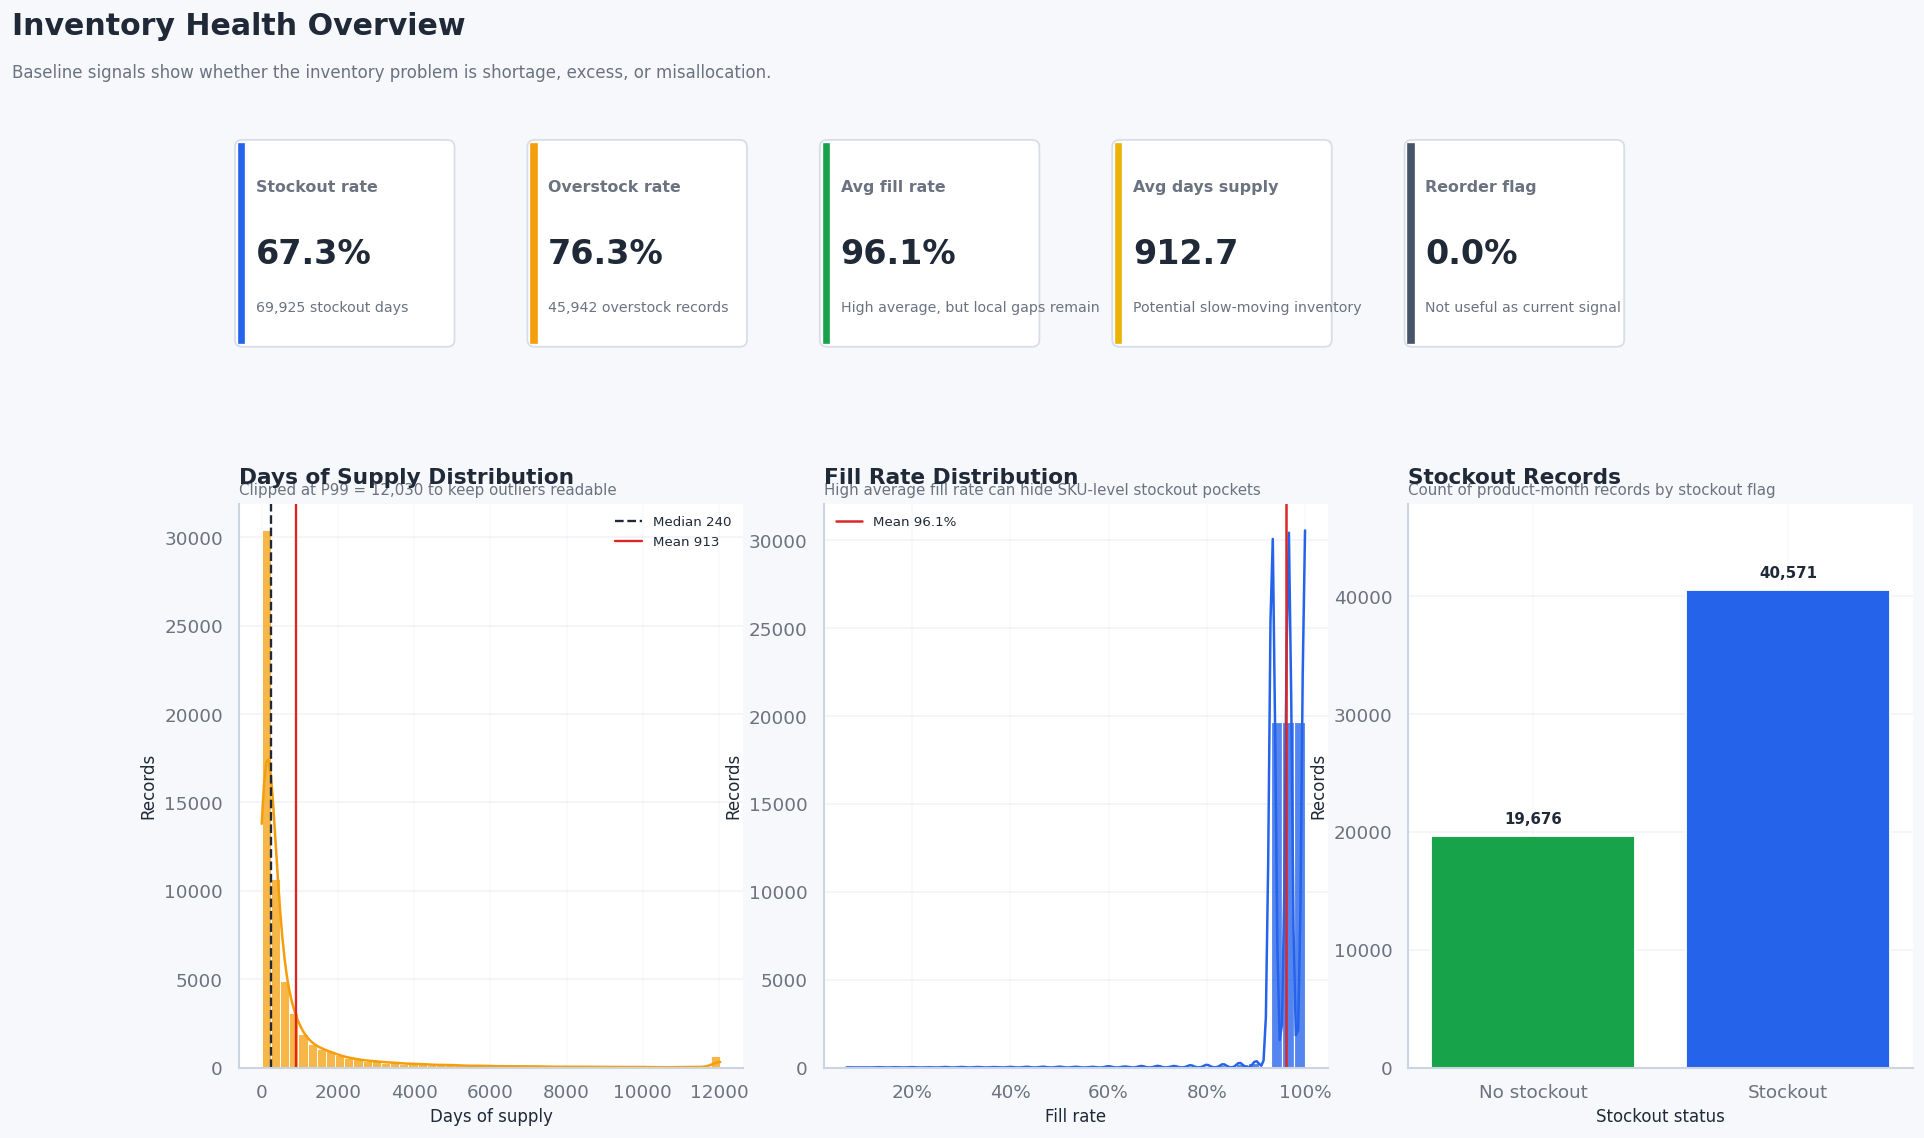

In [4]:
fig = plt.figure(figsize=(18, 10), facecolor=BACKGROUND)
gs = gridspec.GridSpec(2, 6, figure=fig, height_ratios=[0.85, 2.4], hspace=0.42, wspace=0.38)
fig.suptitle('Inventory Health Overview', fontsize=18, fontweight='bold', color=TEXT, x=0.02, ha='left', y=0.99)
fig.text(0.02, 0.935, 'Baseline signals show whether the inventory problem is shortage, excess, or misallocation.', fontsize=10, color=MUTED)

cards = [
    ('Stockout rate', fmt_percent(inv['stockout_flag'].mean()), f"{fmt_number(inv['stockout_days'].sum())} stockout days", PALETTE['stockout']),
    ('Overstock rate', fmt_percent(inv['overstock_flag'].mean()), f"{fmt_number(inv['overstock_flag'].sum())} overstock records", PALETTE['overstock']),
    ('Avg fill rate', fmt_percent(inv['fill_rate'].mean()), 'High average, but local gaps remain', PALETTE['stable']),
    ('Avg days supply', fmt_number(inv['days_of_supply'].mean(), 1), 'Potential slow-moving inventory', PALETTE['warning']),
    ('Reorder flag', fmt_percent(inv['reorder_flag'].mean()), 'Not useful as current signal', PALETTE['neutral'])
]
for idx, (title, value, subtitle, color) in enumerate(cards):
    ax_card = fig.add_subplot(gs[0, idx])
    kpi_card(ax_card, title, value, subtitle, color)

axes = [fig.add_subplot(gs[1, 0:2]), fig.add_subplot(gs[1, 2:4]), fig.add_subplot(gs[1, 4:6])]

p99_days = inv['days_of_supply'].quantile(0.99)
days_clipped = inv['days_of_supply'].clip(upper=p99_days)
sns.histplot(days_clipped, bins=50, kde=True, ax=axes[0], color=PALETTE['overstock'], alpha=0.75, edgecolor='white')
axes[0].axvline(inv['days_of_supply'].median(), color=PALETTE['ink'], linestyle='--', linewidth=1.4, label=f"Median {fmt_number(inv['days_of_supply'].median(), 0)}")
axes[0].axvline(inv['days_of_supply'].mean(), color=PALETTE['volatile'], linestyle='-', linewidth=1.4, label=f"Mean {fmt_number(inv['days_of_supply'].mean(), 0)}")
clean_axis(axes[0], 'Days of Supply Distribution', 'Days of supply', 'Records', subtitle=f'Clipped at P99 = {fmt_number(p99_days)} to keep outliers readable')
axes[0].legend(frameon=False, fontsize=8)

sns.histplot(inv['fill_rate'], bins=40, kde=True, ax=axes[1], color=PALETTE['stockout'], alpha=0.78, edgecolor='white')
axes[1].axvline(inv['fill_rate'].mean(), color=PALETTE['volatile'], linewidth=1.5, label=f"Mean {fmt_percent(inv['fill_rate'].mean())}")
clean_axis(axes[1], 'Fill Rate Distribution', 'Fill rate', 'Records', subtitle='High average fill rate can hide SKU-level stockout pockets')
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].legend(frameon=False, fontsize=8)

stockout_counts = inv['stockout_flag'].value_counts().sort_index()
bar_colors = [PALETTE['stable'], PALETTE['stockout']]
axes[2].bar(['No stockout', 'Stockout'], stockout_counts.values, color=bar_colors, edgecolor='white', linewidth=1.1)
clean_axis(axes[2], 'Stockout Records', 'Stockout status', 'Records', subtitle='Count of product-month records by stockout flag')
label_vbars(axes[2], fmt=lambda v: fmt_number(v))

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


In [5]:
stockout_rate = inv['stockout_flag'].mean()
overstock_rate = inv['overstock_flag'].mean()
fill_rate_avg = inv['fill_rate'].mean()
days_supply_avg = inv['days_of_supply'].mean()
reorder_rate = inv['reorder_flag'].mean()
stockout_days_total = inv['stockout_days'].sum()

descriptive_key_takeaways = pd.DataFrame({
    'Metric': [
        'Stockout rate',
        'Overstock rate',
        'Average fill rate',
        'Average days of supply',
        'Reorder flag rate',
        'Total stockout days'
    ],
    'Value': [
        fmt_percent(stockout_rate),
        fmt_percent(overstock_rate),
        fmt_percent(fill_rate_avg),
        fmt_number(days_supply_avg, 1),
        fmt_percent(reorder_rate),
        fmt_number(stockout_days_total)
    ],
    'Interpretation': [
        'Availability gap appears repeatedly across product-month records',
        'Capital is also tied up in excess inventory',
        'High average fill rate can hide SKU-level stockout pockets',
        'Very high value suggests slow-moving or misallocated stock',
        'Current reorder flag is not useful as an operational signal',
        'Total duration of missed availability across the catalog'
    ]
})

display(descriptive_key_takeaways)


,Metric,Value,Interpretation
0,Stockout rate,67.3%,Availability gap appears repeatedly across pro...
1,Overstock rate,76.3%,Capital is also tied up in excess inventory
2,Average fill rate,96.1%,High average fill rate can hide SKU-level stoc...
3,Average days of supply,912.7,Very high value suggests slow-moving or misall...
4,Reorder flag rate,0.0%,Current reorder flag is not useful as an opera...
5,Total stockout days,"69,925",Total duration of missed availability across t...


### Nhận xét tổng quan tồn kho

Biểu đồ và bảng KPI cho thấy một nghịch lý lớn: tỷ lệ thiếu hàng là **67.3%**, nhưng tỷ lệ dư hàng cũng lên tới **76.3%**. Nói đơn giản, doanh nghiệp vừa có nhiều thời điểm không đủ hàng để bán, vừa có rất nhiều hàng đang nằm trong kho.

Nếu công ty thật sự thiếu hàng trên toàn hệ thống, ta thường kỳ vọng tỷ lệ dư hàng thấp. Nhưng ở đây hai chỉ số cùng cao, nên cách hiểu hợp lý hơn là: **hàng có trong hệ thống, nhưng chưa được đặt đúng nơi cần bán**. Một số mã/tháng thiếu hàng, trong khi mã/tháng khác lại dư hàng.

Tỷ lệ đáp ứng đơn hàng trung bình vẫn cao (**96.1%**) cũng củng cố nhận định này. Hệ thống không phải lúc nào cũng vận hành kém, nhưng có nhiều điểm đứt gãy cục bộ theo mã sản phẩm hoặc thời điểm.

**Việc nên làm:** không nên nhập thêm hàng cho toàn bộ danh mục. Cần theo dõi tồn kho ở cấp mã sản phẩm theo từng tháng để biết chỗ nào thiếu thật, chỗ nào dư thật.

**Kết luận:** Vấn đề lớn nhất không phải “thiếu hàng”, mà là **phân bổ hàng chưa đúng mã sản phẩm và chưa đúng thời điểm**.

## 4. [Diagnostic] Phân tích theo category / segment / sản phẩm

Sau khi biết doanh nghiệp vừa thiếu vừa dư hàng, câu hỏi tiếp theo là: vấn đề nằm ở đâu?

Phần này chia dữ liệu theo nhóm sản phẩm như category và segment. Cách làm này giúp stakeholder không bị chìm trong hàng nghìn mã sản phẩm, mà nhìn được nhóm nào đang đáng chú ý nhất.

Cách đọc phần này rất đơn giản:

- Nhóm có tỷ lệ thiếu hàng cao: có thể đang không được bổ sung hàng kịp.
- Nhóm có số ngày tồn kho cao: có thể đang bán chậm hoặc nhập quá nhiều.
- Nhóm vừa thiếu vừa dư: cần kiểm tra sâu vì có thể đang sai cơ cấu hàng, tức là dư ở mã này nhưng thiếu ở mã khác.

Mục tiêu của phần này là khoanh vùng “khu vực cháy lớn nhất” trước khi đi xuống cấp mã sản phẩm.

In [6]:
category_stockout = (
    inv.groupby('category')
    .agg(
        records=('product_id', 'size'),
        stockout_rate=('stockout_flag', 'mean'),
        overstock_rate=('overstock_flag', 'mean'),
        avg_fill_rate=('fill_rate', 'mean'),
        avg_days_of_supply=('days_of_supply', 'mean'),
        total_stockout_days=('stockout_days', 'sum'),
        total_units_sold=('units_sold', 'sum')
    )
    .reset_index()
    .sort_values('stockout_rate', ascending=False)
)

segment_stockout = (
    inv.groupby('segment')
    .agg(
        records=('product_id', 'size'),
        stockout_rate=('stockout_flag', 'mean'),
        overstock_rate=('overstock_flag', 'mean'),
        avg_fill_rate=('fill_rate', 'mean'),
        avg_days_of_supply=('days_of_supply', 'mean'),
        total_stockout_days=('stockout_days', 'sum'),
        total_units_sold=('units_sold', 'sum')
    )
    .reset_index()
    .sort_values('stockout_rate', ascending=False)
)

display(category_stockout)
display(segment_stockout.head(15))


,category,records,stockout_rate,overstock_rate,avg_fill_rate,avg_days_of_supply,total_stockout_days,total_units_sold
1,GenZ,4674,0.6829,0.7163,0.9617,718.8122,5368,48695
2,Outdoor,21050,0.6735,0.7985,0.9627,"1,068.8378",23552,337510
3,Streetwear,31020,0.6732,0.7493,0.9602,887.1367,36993,511467
0,Casual,3503,0.6620,0.7259,0.9618,459.1326,4012,31202


,segment,records,stockout_rate,overstock_rate,avg_fill_rate,avg_days_of_supply,total_stockout_days,total_units_sold
7,Trendy,4674,0.6829,0.7163,0.9617,718.8122,5368,48695
2,Balanced,6622,0.6789,0.7240,0.9581,837.8431,8327,135119
5,Premium,3182,0.6788,0.7894,0.9616,822.4648,3669,40874
4,Performance,7673,0.6727,0.7468,0.9612,745.6083,8927,125619
0,Activewear,18290,0.6726,0.7930,0.9627,"1,091.6399",20484,298460
3,Everyday,13598,0.6724,0.7805,0.9598,"1,113.7547",16419,236495
6,Standard,3127,0.6658,0.6732,0.9646,353.3401,3320,14234
1,All-weather,3081,0.6605,0.7582,0.9631,494.7097,3411,29378


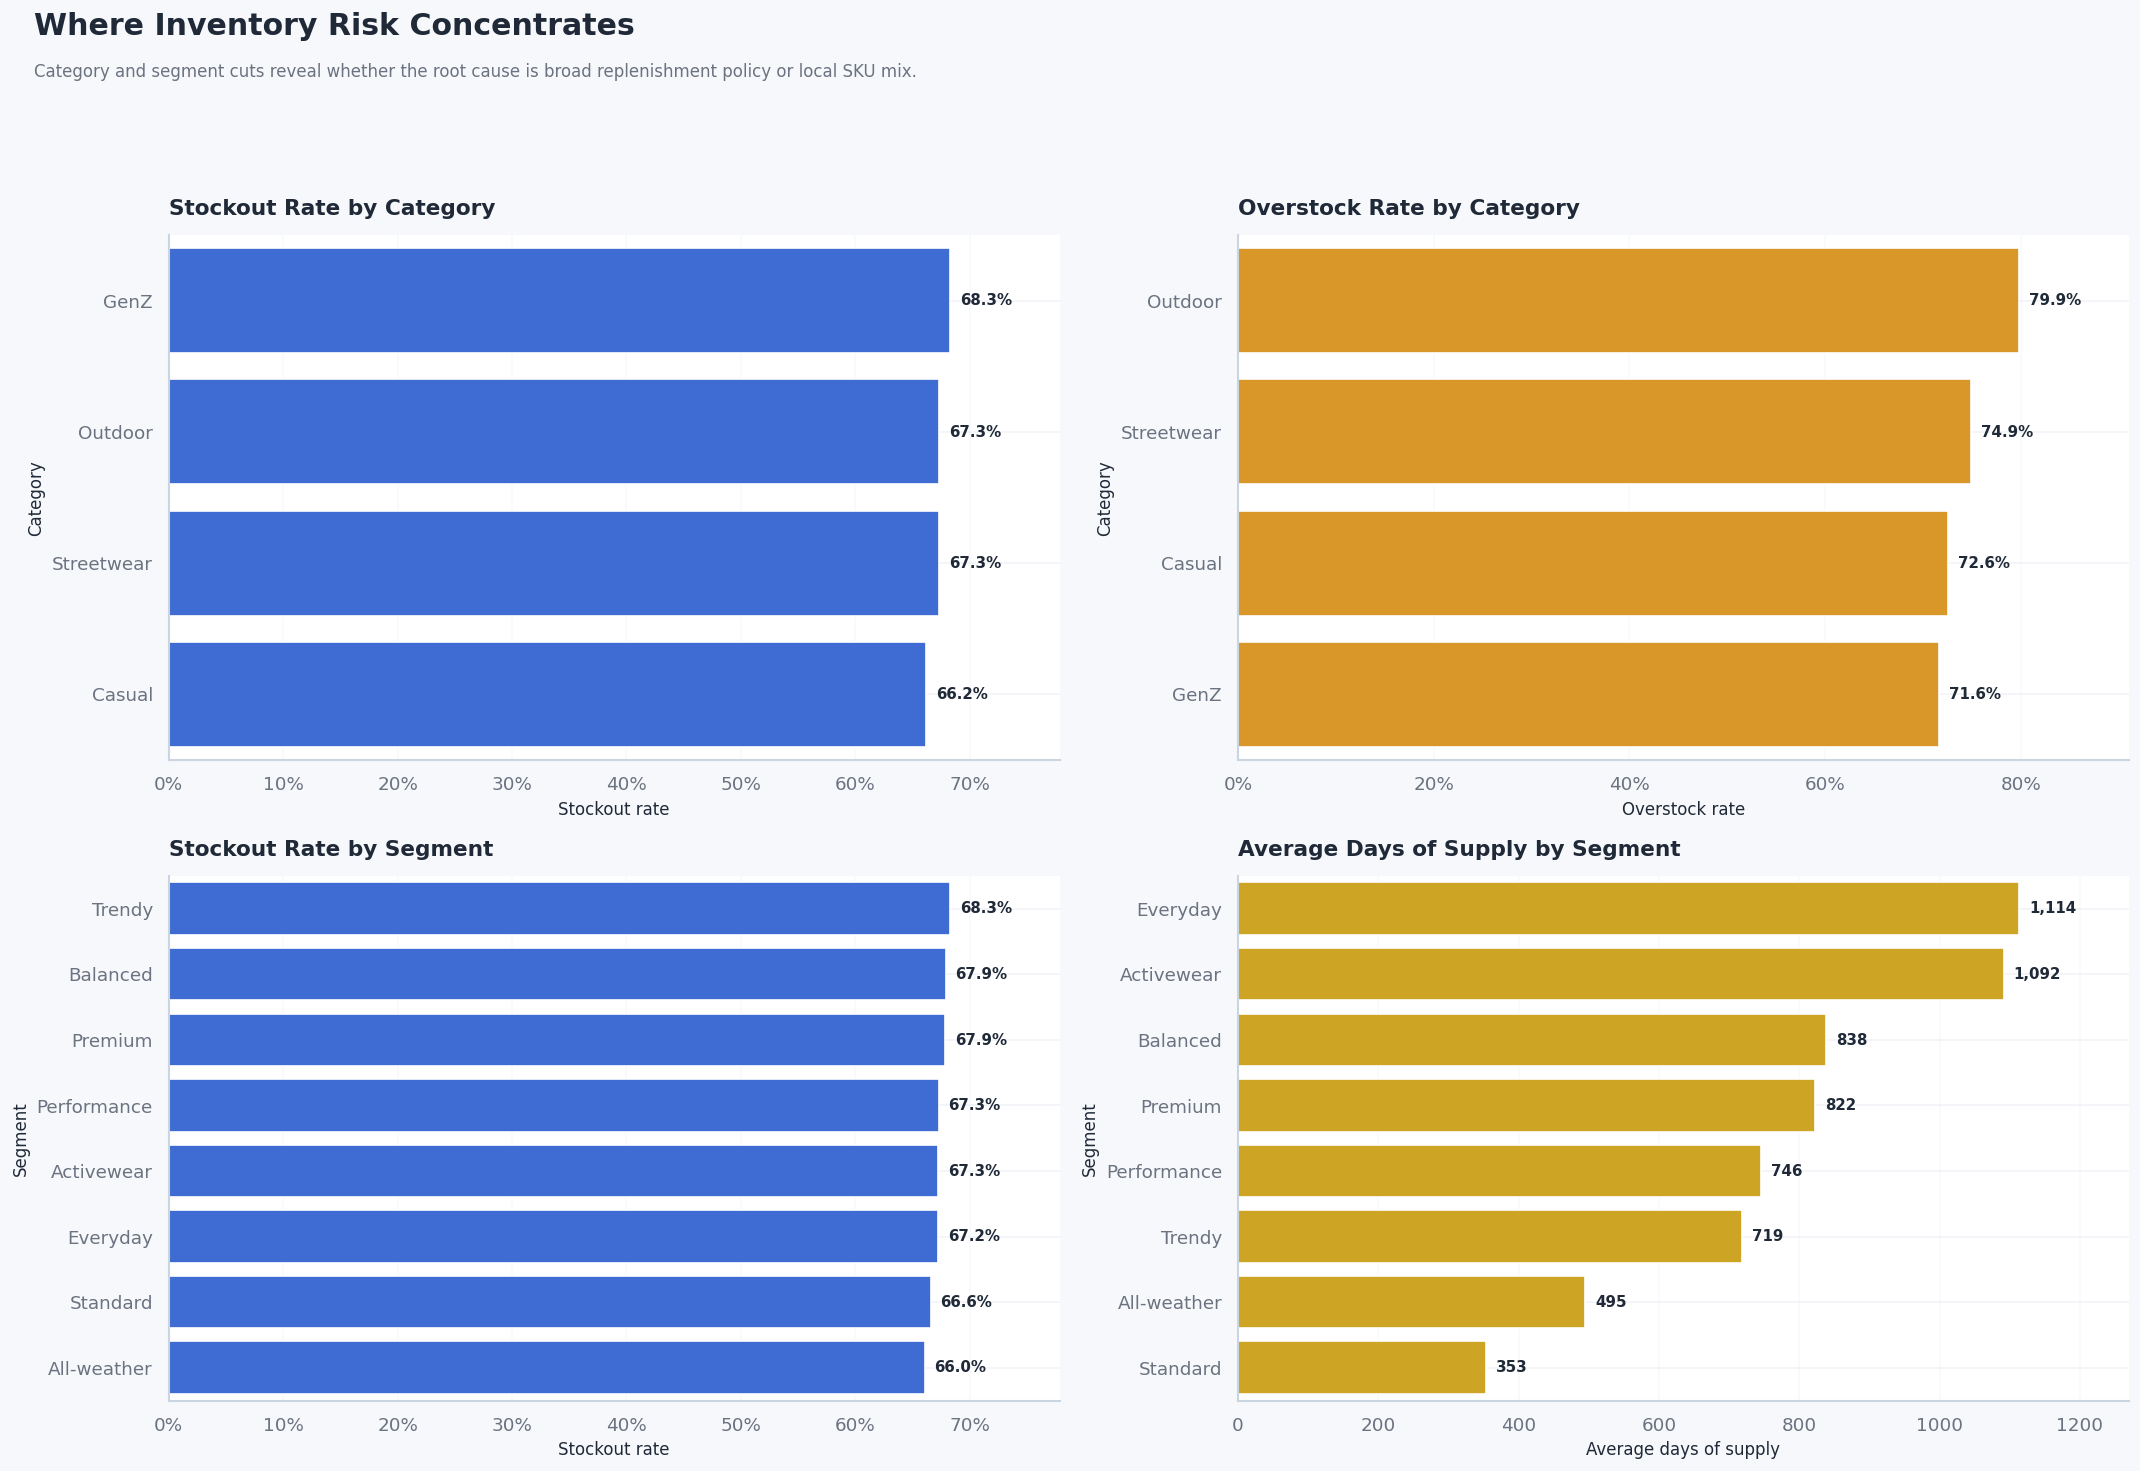

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12), facecolor=BACKGROUND)
fig.suptitle('Where Inventory Risk Concentrates', fontsize=18, fontweight='bold', color=TEXT, x=0.02, ha='left', y=1.02)
fig.text(0.02, 0.975, 'Category and segment cuts reveal whether the root cause is broad replenishment policy or local SKU mix.', fontsize=10, color=MUTED)

sns.barplot(data=category_stockout, x='stockout_rate', y='category', ax=axes[0, 0], color=PALETTE['stockout'], edgecolor='white')
clean_axis(axes[0, 0], 'Stockout Rate by Category', 'Stockout rate', 'Category')
axes[0, 0].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
label_hbars(axes[0, 0], fmt=lambda v: fmt_percent(v))

category_overstock = category_stockout.sort_values('overstock_rate', ascending=False)
sns.barplot(data=category_overstock, x='overstock_rate', y='category', ax=axes[0, 1], color=PALETTE['overstock'], edgecolor='white')
clean_axis(axes[0, 1], 'Overstock Rate by Category', 'Overstock rate', 'Category')
axes[0, 1].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
label_hbars(axes[0, 1], fmt=lambda v: fmt_percent(v))

segment_plot = segment_stockout.head(12)
sns.barplot(data=segment_plot, x='stockout_rate', y='segment', ax=axes[1, 0], color=PALETTE['stockout'], edgecolor='white')
clean_axis(axes[1, 0], 'Stockout Rate by Segment', 'Stockout rate', 'Segment')
axes[1, 0].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
label_hbars(axes[1, 0], fmt=lambda v: fmt_percent(v))

segment_days = segment_stockout.sort_values('avg_days_of_supply', ascending=False).head(12)
sns.barplot(data=segment_days, x='avg_days_of_supply', y='segment', ax=axes[1, 1], color=PALETTE['warning'], edgecolor='white')
clean_axis(axes[1, 1], 'Average Days of Supply by Segment', 'Average days of supply', 'Segment')
label_hbars(axes[1, 1], fmt=lambda v: fmt_number(v, 0))

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


In [8]:
top_stockout_cat = category_stockout.iloc[0]
top_overstock_cat = category_stockout.sort_values('overstock_rate', ascending=False).iloc[0]
top_days_segment = segment_stockout.sort_values('avg_days_of_supply', ascending=False).iloc[0]
spread_stockout = category_stockout['stockout_rate'].max() - category_stockout['stockout_rate'].min()

misallocation_candidates = category_stockout[
    (category_stockout['stockout_rate'] >= category_stockout['stockout_rate'].median()) &
    (category_stockout['overstock_rate'] >= category_stockout['overstock_rate'].median())
]
misallocation_text = ', '.join(misallocation_candidates['category'].head(5).tolist())

diagnostic_category_takeaways = pd.DataFrame({
    'Signal': [
        'Highest stockout category',
        'Highest overstock category',
        'Highest days-of-supply segment',
        'Stockout spread across categories',
        'Potential misallocation category'
    ],
    'Finding': [
        f"{top_stockout_cat['category']} ({fmt_percent(top_stockout_cat['stockout_rate'])})",
        f"{top_overstock_cat['category']} ({fmt_percent(top_overstock_cat['overstock_rate'])})",
        f"{top_days_segment['segment']} ({fmt_number(top_days_segment['avg_days_of_supply'], 1)} days)",
        fmt_percent(spread_stockout),
        misallocation_text if misallocation_text else 'No category above both medians'
    ],
    'Why it matters': [
        'First category to audit for replenishment or allocation gaps',
        'First category to audit for locked capital and slow movement',
        'Segment likely carrying excess inventory duration',
        'Small spread means the issue is broad, not isolated',
        'High stockout and high overstock together suggest wrong SKU/timing mix'
    ]
})

display(diagnostic_category_takeaways)


,Signal,Finding,Why it matters
0,Highest stockout category,GenZ (68.3%),First category to audit for replenishment or a...
1,Highest overstock category,Outdoor (79.9%),First category to audit for locked capital and...
2,Highest days-of-supply segment,"Everyday (1,113.8 days)",Segment likely carrying excess inventory duration
3,Stockout spread across categories,2.1%,"Small spread means the issue is broad, not iso..."
4,Potential misallocation category,Outdoor,High stockout and high overstock together sugg...


### Nhận xét theo category và segment

Nhìn theo category, **GenZ** có tỷ lệ thiếu hàng cao nhất (**68.3%**), nhưng category thấp nhất cũng đã ở mức **66.2%**. Khoảng cách giữa nhóm cao nhất và thấp nhất chỉ khoảng **2.1 điểm phần trăm**, nghĩa là thiếu hàng không phải vấn đề của riêng một category. Nó xuất hiện khá rộng trên toàn danh mục.

Tuy nhiên, **Outdoor** là nhóm đáng chú ý vì vừa có tỷ lệ dư hàng cao nhất (**79.9%**), vừa nằm trong vùng thiếu hàng cao. Với stakeholder, đây là tín hiệu quan trọng: nhóm này không đơn giản là bán chậm hay thiếu hàng, mà có thể đang sai cơ cấu hàng.

Ở cấp segment, **Everyday** và **Activewear** có số ngày tồn kho trung bình rất cao. Điều này gợi ý rằng một phần hàng đang nằm quá lâu trong kho, làm vốn bị kẹt.

**Việc nên làm:** kiểm tra Outdoor và các segment có ngày tồn kho cao ở cấp mã sản phẩm. Cần phân biệt mã nào cần bổ sung hàng và mã nào cần giảm nhập/xả hàng.

**Kết luận:** Thiếu hàng là vấn đề rộng, nhưng **Outdoor và các segment tồn kho lâu là nơi cần chẩn đoán sâu trước**.

## 5. [Diagnostic] Ước tính doanh thu bị mất do thiếu hàng

Tỷ lệ thiếu hàng chỉ cho biết vấn đề có xảy ra, nhưng chưa cho biết vấn đề đó lớn đến mức nào. Ban lãnh đạo thường cần câu trả lời bằng tiền: thiếu hàng làm mất bao nhiêu doanh thu và lợi nhuận?

Vì dữ liệu không có “nhu cầu thật” của khách hàng, notebook dùng một cách ước tính đơn giản: lấy doanh số trung bình 3 tháng trước làm mức nhu cầu kỳ vọng. Nếu tháng hiện tại bị thiếu hàng và bán thấp hơn mức kỳ vọng, phần chênh lệch được xem là số lượng có thể đã bán thêm nếu có đủ hàng.

Cách này không hoàn hảo, nhưng dễ hiểu và đủ tốt cho mục tiêu EDA: xác định quy mô thiệt hại và nhóm sản phẩm cần ưu tiên.

In [9]:
inv_lost = inv.sort_values(['product_id', 'snapshot_date']).copy()

inv_lost['demand_est_3m'] = (
    inv_lost
    .groupby('product_id')['units_sold']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

inv_lost['lost_units_est'] = np.where(
    inv_lost['stockout_flag'] == 1,
    np.maximum(0, inv_lost['demand_est_3m'] - inv_lost['units_sold']),
    0
)

inv_lost['lost_revenue_est'] = inv_lost['lost_units_est'] * inv_lost['price']
inv_lost['lost_margin_est'] = inv_lost['lost_units_est'] * inv_lost['gross_margin_per_unit']

lost_summary = pd.DataFrame({
    'Chỉ số': [
        'Tổng lost units ước tính',
        'Tổng lost revenue ước tính',
        'Tổng lost gross margin ước tính',
        'Số bản ghi có lost revenue > 0'
    ],
    'Giá trị': [
        inv_lost['lost_units_est'].sum(),
        inv_lost['lost_revenue_est'].sum(),
        inv_lost['lost_margin_est'].sum(),
        (inv_lost['lost_revenue_est'] > 0).sum()
    ]
})

display(lost_summary)

lost_by_category = (
    inv_lost.groupby('category')
    .agg(
        lost_units=('lost_units_est', 'sum'),
        lost_revenue=('lost_revenue_est', 'sum'),
        lost_margin=('lost_margin_est', 'sum'),
        stockout_days=('stockout_days', 'sum'),
        units_sold=('units_sold', 'sum')
    )
    .reset_index()
    .sort_values('lost_revenue', ascending=False)
)

top_lost_products = (
    inv_lost.groupby(['product_id', 'product_name', 'category', 'segment'])
    .agg(
        lost_units=('lost_units_est', 'sum'),
        lost_revenue=('lost_revenue_est', 'sum'),
        lost_margin=('lost_margin_est', 'sum'),
        stockout_days=('stockout_days', 'sum'),
        units_sold=('units_sold', 'sum')
    )
    .reset_index()
    .sort_values('lost_revenue', ascending=False)
)

display(lost_by_category)
display(top_lost_products.head(20))
lost_by_category.to_csv(OUTPUT_DIR / 'lost_by_category.csv', index=False)


,Chỉ số,Giá trị
0,Tổng lost units ước tính,"151,803.3333"
1,Tổng lost revenue ước tính,"799,873,483.2385"
2,Tổng lost gross margin ước tính,"161,878,448.6692"
3,Số bản ghi có lost revenue > 0,"21,088.0000"


,category,lost_units,lost_revenue,lost_margin,stockout_days,units_sold
3,Streetwear,"83,967.3333","642,350,431.0850","128,502,771.0139",36993,511467
2,Outdoor,"53,044.6667","114,309,205.5836","25,047,061.7617",23552,337510
0,Casual,"4,965.5000","21,843,241.5394","3,421,062.0418",4012,31202
1,GenZ,"9,825.8333","21,370,605.0306","4,907,553.8517",5368,48695


,product_id,product_name,category,segment,lost_units,lost_revenue,lost_margin,stockout_days,units_sold
315,487,SaigonFlex UM-92,Streetwear,Balanced,"1,463.3333","19,052,306.0484","2,915,002.8254",82,9623
279,438,SaigonFlex UM-43,Streetwear,Balanced,"1,058.3333","12,402,112.1775","5,331,668.0251",174,9124
574,826,HanoiStreet UM-10,Streetwear,Balanced,972.6667,"12,382,441.0134","619,122.0507",110,8315
418,604,SaigonFlex UC-69,Streetwear,Everyday,"1,741.0000","10,681,555.2641","3,470,437.3053",132,10506
319,491,SaigonFlex UM-96,Streetwear,Balanced,954.3333,"10,555,003.5331","527,750.1767",155,7048
1570,2332,VietMotion UE-06,Streetwear,Performance,"1,658.3333","9,617,718.0092","2,064,924.0566",121,9386
1403,2045,UrbanVN UE-05,Streetwear,Performance,"1,675.6667","9,332,562.3487","4,311,643.8051",116,10376
305,475,SaigonFlex UM-80,Streetwear,Balanced,690.0000,"8,698,297.6790","1,770,103.5777",52,6434
610,927,HanoiStreet UE-36,Streetwear,Performance,"1,468.0000","8,603,014.6047","430,150.7302",120,9002
1410,2054,UrbanVN UE-14,Streetwear,Performance,"1,144.5000","8,093,447.9997","404,672.4000",143,7069


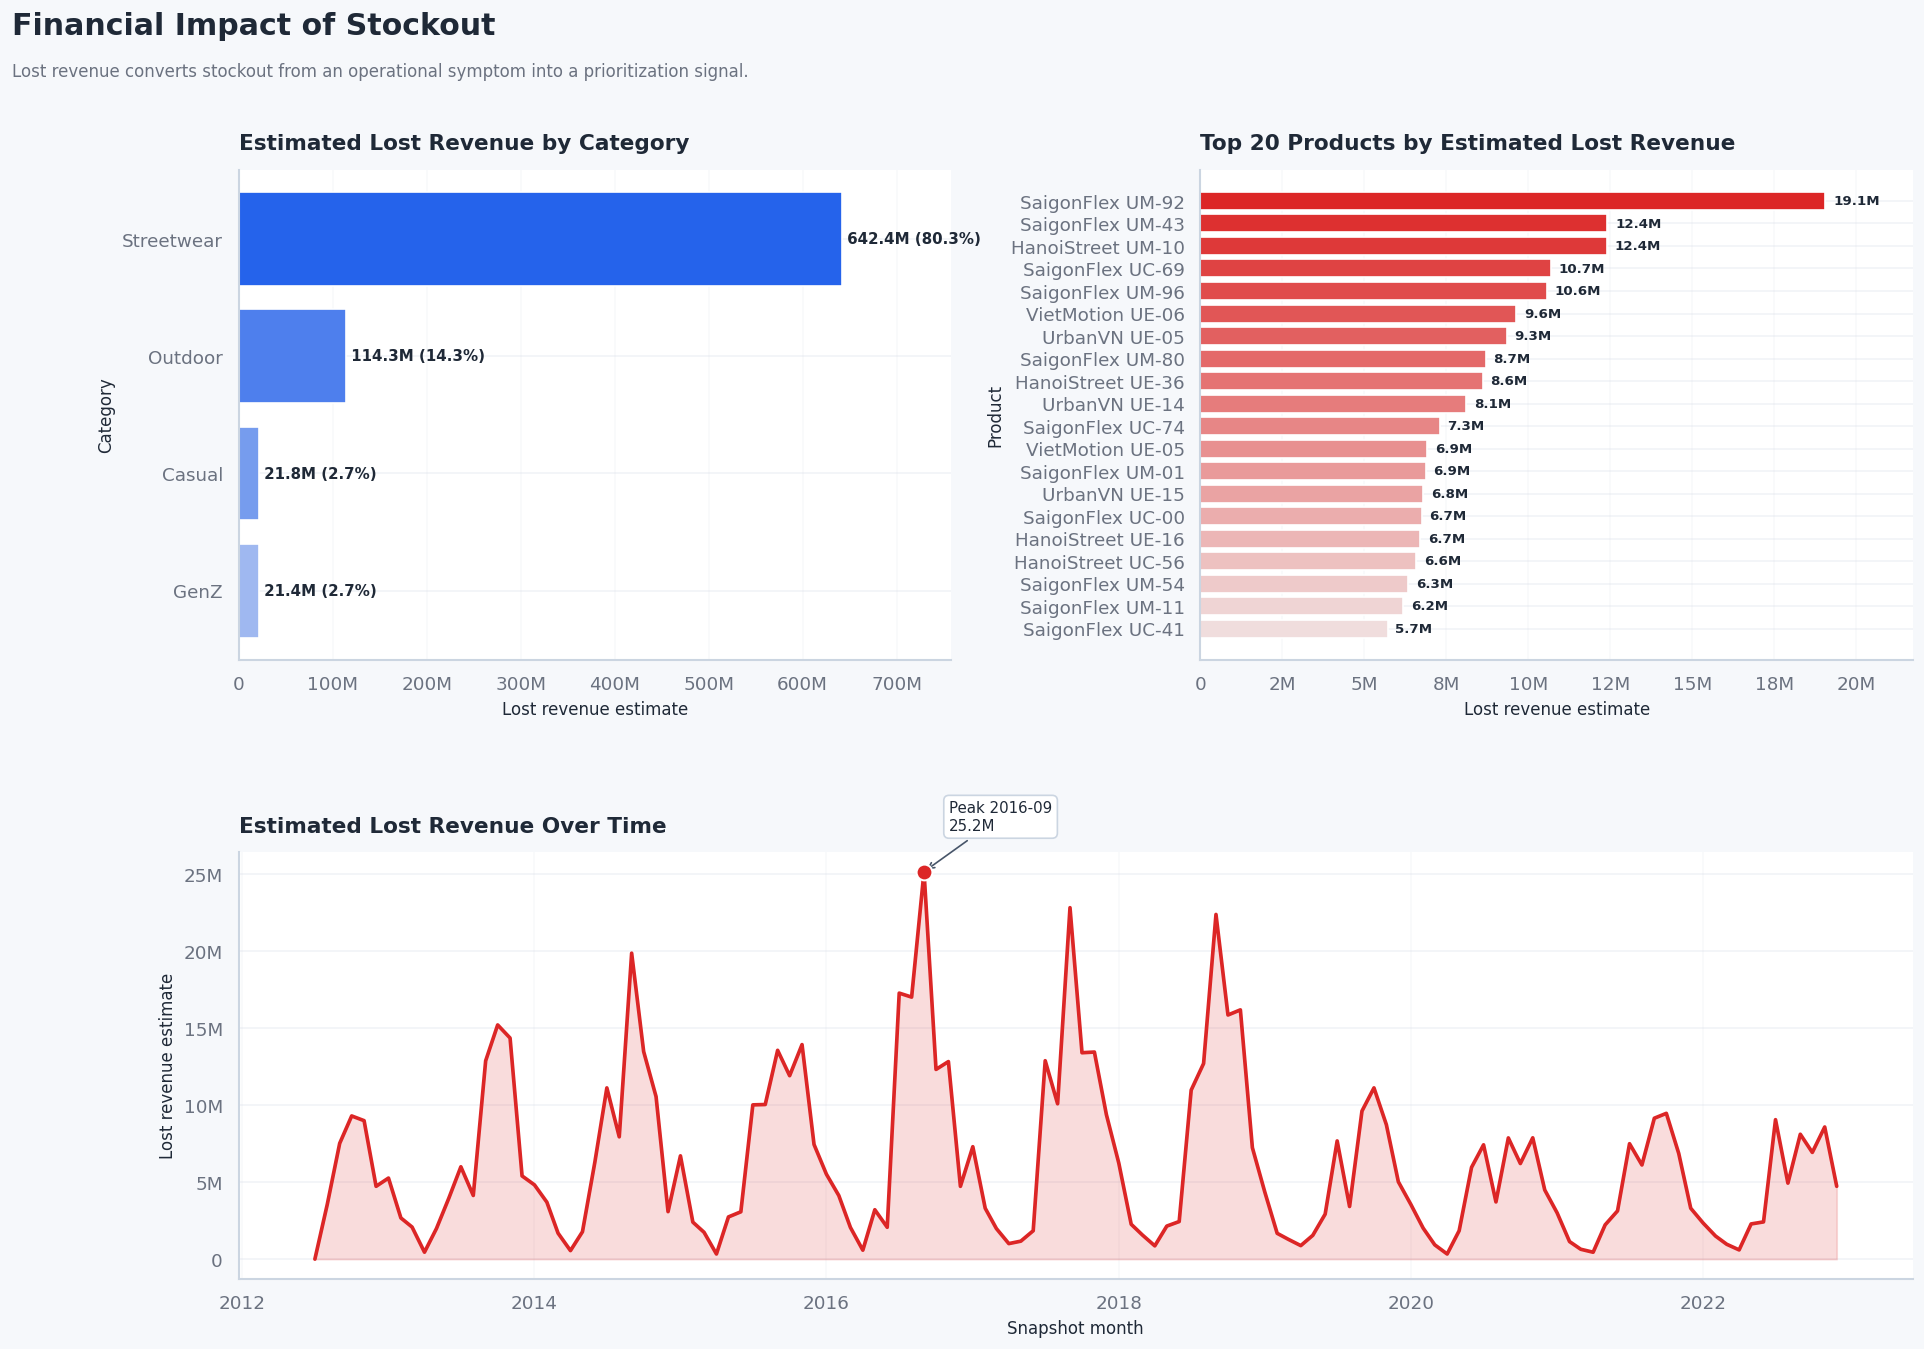

In [10]:
fig = plt.figure(figsize=(18, 12), facecolor=BACKGROUND)
gs = gridspec.GridSpec(2, 2, figure=fig, height_ratios=[1.15, 1.0], hspace=0.42, wspace=0.35)
fig.suptitle('Financial Impact of Stockout', fontsize=18, fontweight='bold', color=TEXT, x=0.02, ha='left', y=0.99)
fig.text(0.02, 0.945, 'Lost revenue converts stockout from an operational symptom into a prioritization signal.', fontsize=10, color=MUTED)

ax_cat = fig.add_subplot(gs[0, 0])
lost_cat_plot = lost_by_category.sort_values('lost_revenue', ascending=True).copy()
lost_cat_plot['share'] = lost_cat_plot['lost_revenue'] / lost_cat_plot['lost_revenue'].sum()
cat_colors = sns.light_palette(PALETTE['stockout'], n_colors=len(lost_cat_plot) + 2)[2:]
ax_cat.barh(lost_cat_plot['category'], lost_cat_plot['lost_revenue'], color=cat_colors, edgecolor='white')
clean_axis(ax_cat, 'Estimated Lost Revenue by Category', 'Lost revenue estimate', 'Category')
ax_cat.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: fmt_currency(x, 0)))
ax_cat.margins(x=0.18)
for patch, (_, row) in zip(ax_cat.patches, lost_cat_plot.iterrows()):
    ax_cat.text(patch.get_width(), patch.get_y() + patch.get_height() / 2, f" {fmt_currency(row['lost_revenue'])} ({fmt_percent(row['share'])})", va='center', ha='left', fontsize=9, weight='bold')

ax_prod = fig.add_subplot(gs[0, 1])
top20 = top_lost_products.head(20).sort_values('lost_revenue', ascending=True)
prod_colors = sns.light_palette(PALETTE['volatile'], n_colors=len(top20) + 2)[2:]
ax_prod.barh(top20['product_name'], top20['lost_revenue'], color=prod_colors, edgecolor='white')
clean_axis(ax_prod, 'Top 20 Products by Estimated Lost Revenue', 'Lost revenue estimate', 'Product')
ax_prod.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: fmt_currency(x, 0)))
label_hbars(ax_prod, fmt=lambda v: fmt_currency(v, 1), fontsize=8)

ax_time = fig.add_subplot(gs[1, :])
lost_time = inv_lost.groupby('year_month', as_index=False)['lost_revenue_est'].sum()
lost_time['date'] = pd.to_datetime(lost_time['year_month'])
ax_time.plot(lost_time['date'], lost_time['lost_revenue_est'], color=PALETTE['volatile'], linewidth=2.2)
ax_time.fill_between(lost_time['date'], lost_time['lost_revenue_est'], color=PALETTE['volatile'], alpha=0.16)
peak = lost_time.loc[lost_time['lost_revenue_est'].idxmax()]
ax_time.scatter([peak['date']], [peak['lost_revenue_est']], s=90, color=PALETTE['volatile'], edgecolor='white', linewidth=1.2, zorder=5)
ax_time.annotate(
    f"Peak {peak['year_month']}\n{fmt_currency(peak['lost_revenue_est'])}",
    xy=(peak['date'], peak['lost_revenue_est']),
    xytext=(15, 25),
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->', color=PALETTE['neutral'], lw=1),
    fontsize=9,
    color=TEXT,
    bbox=dict(boxstyle='round,pad=0.35', fc='white', ec='#CBD5E1')
)
clean_axis(ax_time, 'Estimated Lost Revenue Over Time', 'Snapshot month', 'Lost revenue estimate')
ax_time.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: fmt_currency(x, 0)))

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


In [11]:
total_lost_units = inv_lost['lost_units_est'].sum()
total_lost_revenue = inv_lost['lost_revenue_est'].sum()
total_lost_margin = inv_lost['lost_margin_est'].sum()
positive_lost_records = (inv_lost['lost_revenue_est'] > 0).sum()
top_lost_cat = lost_by_category.iloc[0]
top_lost_product = top_lost_products.iloc[0]
margin_loss_rate = total_lost_margin / total_lost_revenue if total_lost_revenue else np.nan

lost_revenue_takeaways = pd.DataFrame({
    'Metric': [
        'Estimated lost units',
        'Estimated lost revenue',
        'Estimated lost margin',
        'Records with positive lost revenue',
        'Top lost-revenue category',
        'Top lost-revenue SKU',
        'Lost margin / lost revenue'
    ],
    'Value': [
        fmt_number(total_lost_units),
        fmt_currency(total_lost_revenue),
        fmt_currency(total_lost_margin),
        fmt_number(positive_lost_records),
        f"{top_lost_cat['category']} ({fmt_currency(top_lost_cat['lost_revenue'])})",
        f"{top_lost_product['product_name']} ({fmt_currency(top_lost_product['lost_revenue'])})",
        fmt_percent(margin_loss_rate)
    ]
})

display(lost_revenue_takeaways)


,Metric,Value
0,Estimated lost units,"151,803"
1,Estimated lost revenue,799.9M
2,Estimated lost margin,161.9M
3,Records with positive lost revenue,"21,088"
4,Top lost-revenue category,Streetwear (642.4M)
5,Top lost-revenue SKU,SaigonFlex UM-92 (19.1M)
6,Lost margin / lost revenue,20.2%


### Nhận xét về doanh thu bị mất

Ước tính cho thấy thiếu hàng làm mất khoảng **151,803 sản phẩm bán ra**, tương đương **799.9M doanh thu** và **161.9M lợi nhuận gộp**. Đây là con số đủ lớn để xem thiếu hàng là vấn đề kinh doanh, không chỉ là vấn đề vận hành kho.

Điểm đáng chú ý nhất là **Streetwear** chiếm tới **80.3%** tổng doanh thu bị mất. Nghĩa là nếu muốn thu hồi doanh thu nhanh, doanh nghiệp nên bắt đầu từ Streetwear thay vì chia đều nỗ lực cho tất cả category.

Tuy nhiên, mã sản phẩm mất doanh thu cao nhất chỉ chiếm **2.4%** tổng lost revenue. Điều này nghĩa là không có một “siêu mã” duy nhất gây toàn bộ vấn đề. Doanh nghiệp cần xử lý theo danh sách nhiều mã ưu tiên.

**Việc nên làm:** ưu tiên kiểm tra Streetwear, sau đó xếp hạng các mã trong nhóm này theo doanh thu bị mất, lợi nhuận và tần suất thiếu hàng.

**Kết luận:** Thiếu hàng đang gây thiệt hại tài chính rõ ràng, và **Streetwear là trọng tâm đầu tiên cần xử lý**.

## 6. [Diagnostic] Dư hàng và vốn bị khóa

Nếu chỉ nhìn phần doanh thu bị mất, ta có thể vội kết luận rằng cần nhập thêm hàng. Nhưng điều đó nguy hiểm, vì doanh nghiệp cũng đang có tình trạng dư hàng.

Phần này trả lời câu hỏi: **bao nhiêu tiền vốn đang bị nằm trong hàng dư?**

Vốn bị khóa là vấn đề quan trọng vì tiền nằm trong kho không thể dùng cho sản phẩm bán tốt hơn, marketing, vận hành hoặc các cơ hội kinh doanh khác. Với ngành thời trang, hàng để quá lâu còn có nguy cơ lỗi mùa, lỗi xu hướng và phải giảm giá.

In [12]:
inv_lost['inventory_value'] = inv_lost['stock_on_hand'] * inv_lost['cogs']

overstock_summary = (
    inv_lost[inv_lost['overstock_flag'] == 1]
    .groupby('category')
    .agg(
        overstock_records=('overstock_flag', 'size'),
        overstock_inventory_value=('inventory_value', 'sum'),
        avg_days_of_supply=('days_of_supply', 'mean'),
        stock_on_hand=('stock_on_hand', 'sum')
    )
    .reset_index()
    .sort_values('overstock_inventory_value', ascending=False)
)

display(overstock_summary)


,category,overstock_records,overstock_inventory_value,avg_days_of_supply,stock_on_hand
3,Streetwear,23242,"32,552,242,382.0529","1,163.7038",5506989
2,Outdoor,16809,"7,879,570,874.2109","1,322.4768",4597053
0,Casual,2543,"1,086,289,860.5583",608.6748,296205
1,GenZ,3348,"821,293,778.0782",979.4861,560759


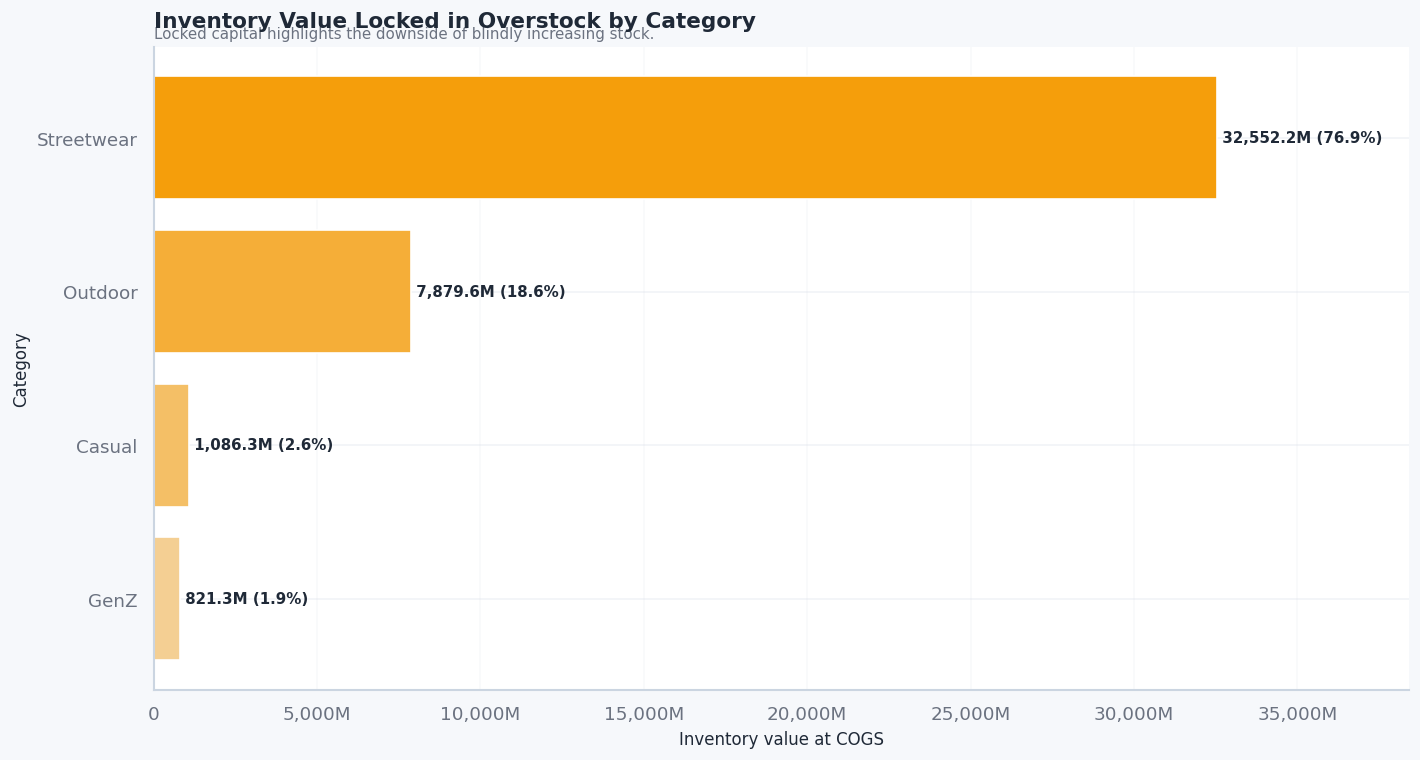

In [13]:
fig, ax = plt.subplots(figsize=(12, 6.5), facecolor=BACKGROUND)
plot_df = overstock_summary.sort_values('overstock_inventory_value', ascending=True).copy()
plot_df['share'] = plot_df['overstock_inventory_value'] / plot_df['overstock_inventory_value'].sum()
colors = sns.light_palette(PALETTE['overstock'], n_colors=len(plot_df) + 2)[2:]
ax.barh(plot_df['category'], plot_df['overstock_inventory_value'], color=colors, edgecolor='white')
clean_axis(
    ax,
    'Inventory Value Locked in Overstock by Category',
    'Inventory value at COGS',
    'Category',
    subtitle='Locked capital highlights the downside of blindly increasing stock.'
)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: fmt_currency(x, 0)))
ax.margins(x=0.18)
for patch, (_, row) in zip(ax.patches, plot_df.iterrows()):
    ax.text(
        patch.get_width(),
        patch.get_y() + patch.get_height() / 2,
        f" {fmt_currency(row['overstock_inventory_value'])} ({fmt_percent(row['share'])})",
        va='center',
        ha='left',
        fontsize=9,
        weight='bold',
        color=TEXT
    )
plt.tight_layout()
plt.show()


In [14]:
total_locked_capital = overstock_summary['overstock_inventory_value'].sum()
top_overstock_value = overstock_summary.iloc[0]
overstock_records = inv_lost['overstock_flag'].sum()

overstock_takeaways = pd.DataFrame({
    'Metric': [
        'Total locked capital in overstock records',
        'Overstock records',
        'Top locked-capital category',
        'Top category stock on hand',
        'Top category avg days of supply'
    ],
    'Value': [
        fmt_currency(total_locked_capital),
        fmt_number(overstock_records),
        f"{top_overstock_value['category']} ({fmt_currency(top_overstock_value['overstock_inventory_value'])})",
        fmt_number(top_overstock_value['stock_on_hand']),
        fmt_number(top_overstock_value['avg_days_of_supply'], 1)
    ]
})

display(overstock_takeaways)


,Metric,Value
0,Total locked capital in overstock records,"42,339.4M"
1,Overstock records,"45,942"
2,Top locked-capital category,"Streetwear (32,552.2M)"
3,Top category stock on hand,"5,506,989"
4,Top category avg days of supply,"1,163.7"


### Nhận xét về dư hàng và vốn bị khóa

Các bản ghi dư hàng đang khóa khoảng **42,339.4M** theo giá vốn. Riêng **Streetwear** chiếm **32,552.2M**, tương đương **76.9%** tổng vốn bị khóa trong hàng dư.

Điều này tạo ra một phát hiện rất quan trọng: **Streetwear vừa là nhóm mất doanh thu nhiều nhất do thiếu hàng, vừa là nhóm khóa vốn nhiều nhất do dư hàng**. Nếu chỉ nhìn bề mặt, điều này có vẻ mâu thuẫn. Nhưng về kinh doanh, nó thường có nghĩa là Streetwear đang sai cơ cấu tồn kho: có mã dư nhiều, nhưng mã có nhu cầu lại không đủ hàng.

**Việc nên làm:** không nhập thêm Streetwear một cách đại trà. Cần tách từng mã: mã bán tốt và hay thiếu thì tăng hàng; mã dư lâu thì giảm nhập, bundle hoặc markdown.

**Kết luận:** Vấn đề của Streetwear không phải là “cần nhiều hàng hơn”, mà là **cần đúng hàng hơn**.

## 7. [Diagnostic] Ma trận thiếu hàng - dư hàng

Phần này giúp biến dữ liệu thành nhóm hành động dễ hiểu. Thay vì nhìn từng mã sản phẩm riêng lẻ, notebook chia sản phẩm thành 4 nhóm:

- **Thiếu hàng thường xuyên:** cần xem xét tăng tồn an toàn hoặc bổ sung hàng nhanh hơn.
- **Dư hàng:** cần giảm nhập, xả hàng hoặc bundle.
- **Tồn kho biến động:** vừa thiếu vừa dư, cần xem lại dự báo và thời điểm nhập hàng.
- **Ổn định:** chưa cần can thiệp mạnh, chỉ cần theo dõi.

Mục tiêu là tránh một sai lầm phổ biến: dùng cùng một giải pháp cho tất cả sản phẩm.

In [15]:
matrix_df = (
    inv_lost
    .groupby(['product_id', 'product_name', 'category', 'segment'])
    .agg(
        stockout_rate=('stockout_flag', 'mean'),
        overstock_rate=('overstock_flag', 'mean'),
        lost_revenue=('lost_revenue_est', 'sum'),
        inventory_value=('inventory_value', 'mean'),
        total_units_sold=('units_sold', 'sum')
    )
    .reset_index()
)

stockout_median = matrix_df['stockout_rate'].median()
overstock_median = matrix_df['overstock_rate'].median()


def classify_inventory(row):
    if row['stockout_rate'] > stockout_median and row['overstock_rate'] <= overstock_median:
        return 'Thiếu hàng thường xuyên'
    if row['stockout_rate'] <= stockout_median and row['overstock_rate'] > overstock_median:
        return 'Dư hàng'
    if row['stockout_rate'] > stockout_median and row['overstock_rate'] > overstock_median:
        return 'Tồn kho biến động'
    return 'Ổn định'

matrix_df['inventory_group'] = matrix_df.apply(classify_inventory, axis=1)

group_counts = matrix_df['inventory_group'].value_counts().rename_axis('inventory_group').reset_index(name='products')
display(group_counts)
display(matrix_df.sort_values('lost_revenue', ascending=False).head(20))


,inventory_group,products
0,Dư hàng,452
1,Thiếu hàng thường xuyên,449
2,Ổn định,363
3,Tồn kho biến động,360


,product_id,product_name,category,segment,stockout_rate,overstock_rate,lost_revenue,inventory_value,total_units_sold,inventory_group
315,487,SaigonFlex UM-92,Streetwear,Balanced,0.6667,0.8333,"19,052,306.0484","15,073,582.9223",9623,Dư hàng
279,438,SaigonFlex UM-43,Streetwear,Balanced,0.7073,0.6829,"12,402,112.1775","6,246,405.4087",9124,Tồn kho biến động
574,826,HanoiStreet UM-10,Streetwear,Balanced,0.5794,0.9921,"12,382,441.0134","16,390,957.7332",8315,Dư hàng
418,604,SaigonFlex UC-69,Streetwear,Everyday,0.7143,0.9762,"10,681,555.2641","6,868,125.8598",10506,Tồn kho biến động
319,491,SaigonFlex UM-96,Streetwear,Balanced,0.6777,0.7934,"10,555,003.5331","6,671,559.4119",7048,Dư hàng
1570,2332,VietMotion UE-06,Streetwear,Performance,0.6349,0.9524,"9,617,718.0092","5,433,240.3188",9386,Dư hàng
1403,2045,UrbanVN UE-05,Streetwear,Performance,0.6240,0.9280,"9,332,562.3487","4,503,497.2566",10376,Dư hàng
305,475,SaigonFlex UM-80,Streetwear,Balanced,0.5714,1.0000,"8,698,297.6790","8,890,943.3620",6434,Dư hàng
610,927,HanoiStreet UE-36,Streetwear,Performance,0.6752,0.9487,"8,603,014.6047","7,196,865.3013",9002,Dư hàng
1410,2054,UrbanVN UE-14,Streetwear,Performance,0.7222,0.9603,"8,093,447.9997","7,175,593.4023",7069,Tồn kho biến động


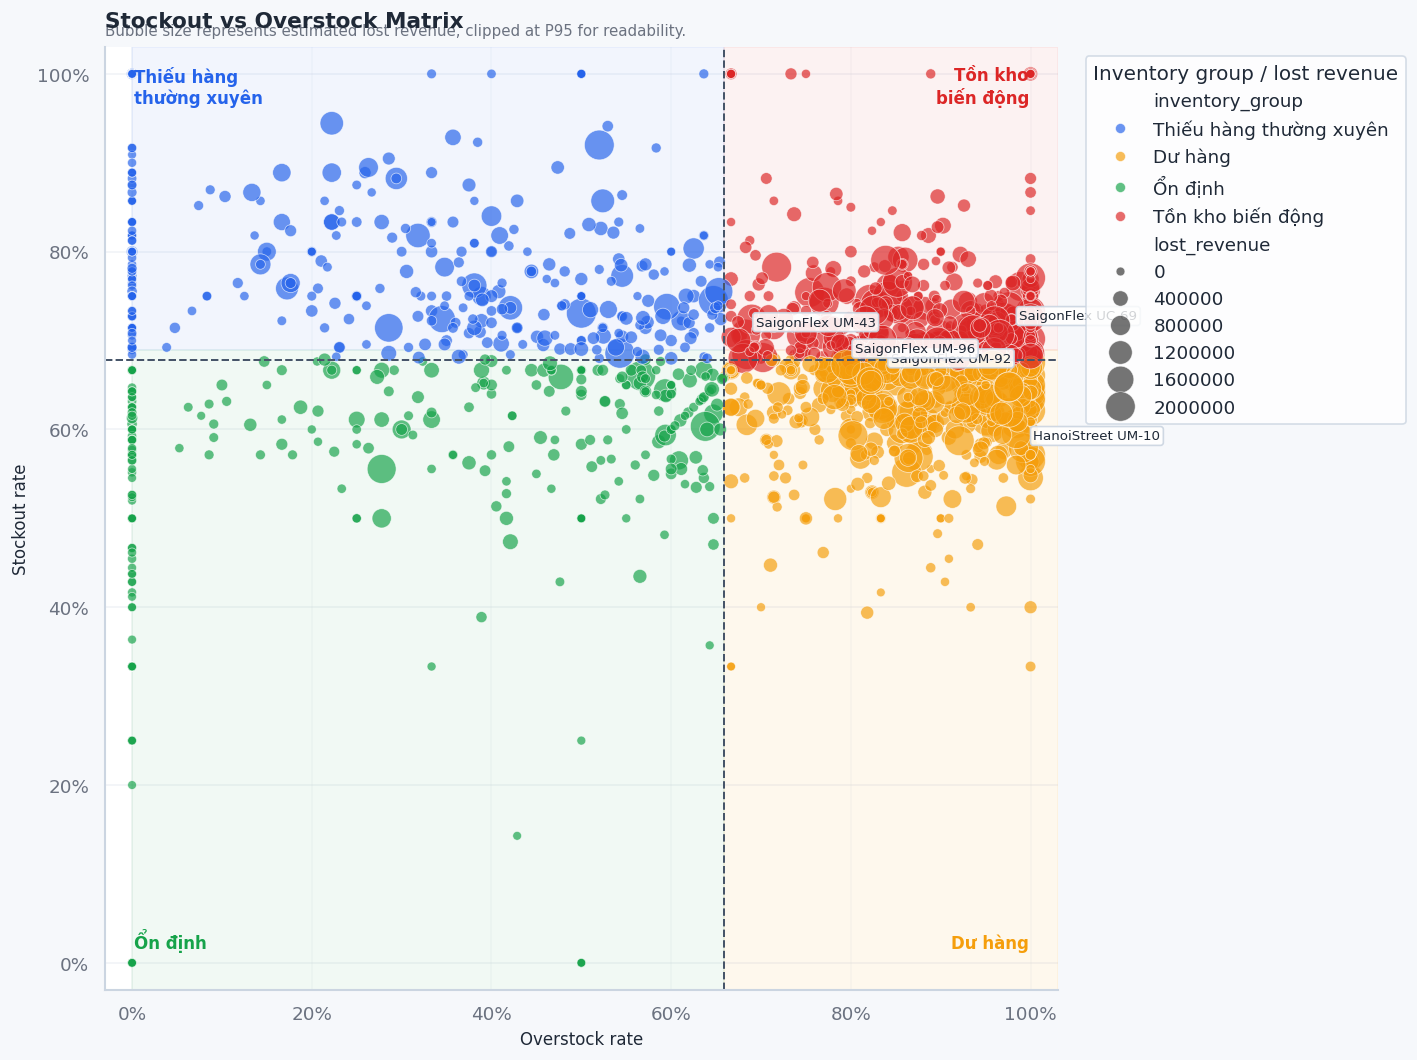

In [16]:
fig, ax = plt.subplots(figsize=(12, 9), facecolor=BACKGROUND)

# Light quadrant backgrounds make the operational interpretation visible before reading the legend.
ax.axvspan(0, overstock_median, ymin=stockout_median, ymax=1, color=PALETTE['stockout'], alpha=0.06)
ax.axvspan(overstock_median, 1.03, ymin=0, ymax=stockout_median, color=PALETTE['overstock'], alpha=0.07)
ax.axvspan(overstock_median, 1.03, ymin=stockout_median, ymax=1, color=PALETTE['volatile'], alpha=0.06)
ax.axvspan(0, overstock_median, ymin=0, ymax=stockout_median, color=PALETTE['stable'], alpha=0.06)

size_max = max(matrix_df['lost_revenue'].quantile(0.95), 1)
sns.scatterplot(
    data=matrix_df,
    x='overstock_rate',
    y='stockout_rate',
    hue='inventory_group',
    size=matrix_df['lost_revenue'].clip(upper=size_max),
    sizes=(28, 320),
    alpha=0.68,
    linewidth=0.45,
    edgecolor='white',
    palette=GROUP_COLORS,
    ax=ax
)
ax.axhline(stockout_median, color=PALETTE['neutral'], linestyle='--', linewidth=1.2)
ax.axvline(overstock_median, color=PALETTE['neutral'], linestyle='--', linewidth=1.2)
ax.text(0.03, 0.98, 'Thiếu hàng\nthường xuyên', transform=ax.transAxes, ha='left', va='top', fontsize=10, weight='bold', color=PALETTE['stockout'])
ax.text(0.97, 0.98, 'Tồn kho\nbiến động', transform=ax.transAxes, ha='right', va='top', fontsize=10, weight='bold', color=PALETTE['volatile'])
ax.text(0.97, 0.04, 'Dư hàng', transform=ax.transAxes, ha='right', va='bottom', fontsize=10, weight='bold', color=PALETTE['overstock'])
ax.text(0.03, 0.04, 'Ổn định', transform=ax.transAxes, ha='left', va='bottom', fontsize=10, weight='bold', color=PALETTE['stable'])

for _, row in matrix_df.nlargest(5, 'lost_revenue').iterrows():
    ax.annotate(
        row['product_name'],
        (row['overstock_rate'], row['stockout_rate']),
        xytext=(6, 5),
        textcoords='offset points',
        fontsize=8,
        color=TEXT,
        bbox=dict(boxstyle='round,pad=0.22', fc='white', ec='#CBD5E1', alpha=0.9)
    )

clean_axis(
    ax,
    'Stockout vs Overstock Matrix',
    'Overstock rate',
    'Stockout rate',
    subtitle='Bubble size represents estimated lost revenue, clipped at P95 for readability.'
)
ax.set_xlim(-0.03, 1.03)
ax.set_ylim(-0.03, 1.03)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend(title='Inventory group / lost revenue', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, edgecolor='#CBD5E1')
plt.tight_layout()
plt.show()


In [17]:
group_count_map = matrix_df['inventory_group'].value_counts().to_dict()
volatile_count = group_count_map.get('Tồn kho biến động', 0)
shortage_count = group_count_map.get('Thiếu hàng thường xuyên', 0)
overstock_count = group_count_map.get('Dư hàng', 0)
stable_count = group_count_map.get('Ổn định', 0)

matrix_group_summary = (
    matrix_df.groupby('inventory_group')
    .agg(
        products=('product_id', 'nunique'),
        avg_stockout_rate=('stockout_rate', 'mean'),
        avg_overstock_rate=('overstock_rate', 'mean'),
        lost_revenue=('lost_revenue', 'sum'),
        avg_inventory_value=('inventory_value', 'mean')
    )
    .reset_index()
    .sort_values('lost_revenue', ascending=False)
)

matrix_group_summary_display = matrix_group_summary.copy()
matrix_group_summary_display['avg_stockout_rate'] = matrix_group_summary_display['avg_stockout_rate'].map(fmt_percent)
matrix_group_summary_display['avg_overstock_rate'] = matrix_group_summary_display['avg_overstock_rate'].map(fmt_percent)
matrix_group_summary_display['lost_revenue'] = matrix_group_summary_display['lost_revenue'].map(fmt_currency)
matrix_group_summary_display['avg_inventory_value'] = matrix_group_summary_display['avg_inventory_value'].map(fmt_currency)

display(matrix_group_summary_display)


,inventory_group,products,avg_stockout_rate,avg_overstock_rate,lost_revenue,avg_inventory_value
0,Dư hàng,452,61.6%,87.2%,397.9M,735.9K
2,Tồn kho biến động,360,74.2%,86.7%,290.2M,579.9K
1,Thiếu hàng thường xuyên,449,83.4%,23.1%,71.0M,89.3K
3,Ổn định,363,51.1%,25.6%,40.7M,89.4K


### Nhận xét từ ma trận thiếu hàng - dư hàng

Ma trận cho thấy danh mục được chia khá đều: **449 mã** thiếu hàng thường xuyên, **452 mã** dư hàng, **360 mã** biến động và **363 mã** ổn định.

Điểm đáng chú ý là nhóm **Dư hàng** lại tạo doanh thu bị mất lớn nhất (**397.9M**). Điều này nghe ngược đời, nhưng có thể hiểu như sau: một sản phẩm có thể nhìn tổng thể là dư hàng, nhưng vẫn bị thiếu ở một số tháng hoặc thiếu đúng thời điểm nhu cầu tăng. Nói cách khác, vấn đề không chỉ là số lượng hàng, mà là hàng có đến đúng lúc hay không.

**Việc nên làm:** mỗi nhóm cần một cách xử lý riêng. Nhóm thiếu hàng thì tăng mức tồn an toàn; nhóm dư hàng thì giảm nhập/xả hàng; nhóm biến động thì kiểm tra lại dự báo và lịch nhập; nhóm ổn định thì tiếp tục theo dõi.

**Kết luận:** Doanh nghiệp không nên dùng một chính sách tồn kho chung cho toàn bộ sản phẩm.

## 8. [Predictive] Điểm đặt hàng lại động

Sau khi hiểu hiện trạng và nguyên nhân, bước tiếp theo là thử xây dựng tín hiệu cảnh báo sớm.

Điểm đặt hàng lại có thể hiểu đơn giản là: **khi tồn kho giảm xuống dưới mức này, doanh nghiệp nên cân nhắc đặt thêm hàng**. Notebook tính mức này dựa trên lượng bán gần đây, thời gian chờ hàng và một phần tồn kho an toàn.

Tuy nhiên, cần nhớ rằng dữ liệu hiện tại là ảnh chụp tồn kho theo tháng. Nếu một sản phẩm thiếu hàng giữa tháng nhưng được nhập lại trước cuối tháng, snapshot cuối tháng có thể không còn thể hiện tình trạng thiếu. Vì vậy, tín hiệu này cần được kiểm tra kỹ trước khi dùng để ra quyết định.

In [18]:
LEAD_TIME_DAYS = 14
Z_SCORE = 1.28

rop_df = inv_lost.sort_values(['product_id', 'snapshot_date']).copy()
rop_df['daily_demand'] = rop_df['units_sold'] / 30

rop_df['avg_daily_demand_3m'] = (
    rop_df
    .groupby('product_id')['daily_demand']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

rop_df['std_daily_demand_3m'] = (
    rop_df
    .groupby('product_id')['daily_demand']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).std())
)

rop_df['std_daily_demand_3m'] = rop_df['std_daily_demand_3m'].fillna(0)
rop_df['lead_time_demand'] = rop_df['avg_daily_demand_3m'] * LEAD_TIME_DAYS
rop_df['safety_stock'] = Z_SCORE * rop_df['std_daily_demand_3m'] * np.sqrt(LEAD_TIME_DAYS)
rop_df['dynamic_rop'] = rop_df['lead_time_demand'] + rop_df['safety_stock']
rop_df['below_dynamic_rop'] = np.where(
    rop_df['dynamic_rop'].notna(),
    (rop_df['stock_on_hand'] < rop_df['dynamic_rop']).astype(int),
    np.nan
)

rop_sample_cols = [
    'snapshot_date', 'product_id', 'product_name', 'stock_on_hand', 'units_sold',
    'avg_daily_demand_3m', 'safety_stock', 'dynamic_rop', 'below_dynamic_rop', 'stockout_flag'
]

display(rop_df[rop_sample_cols].head(15))


,snapshot_date,product_id,product_name,stock_on_hand,units_sold,avg_daily_demand_3m,safety_stock,dynamic_rop,below_dynamic_rop,stockout_flag
0,2022-10-31,1,DragonWear MA-01,3,1,NaN,0.0000,NaN,NaN,1
1,2022-11-30,1,DragonWear MA-01,3,1,0.0333,0.0000,0.4667,0.0000,1
2,2022-12-31,1,DragonWear MA-01,3,1,0.0333,0.0000,0.4667,0.0000,1
3,2016-04-30,3,DragonWear MA-03,35,11,NaN,0.0000,NaN,NaN,1
4,2016-05-31,3,DragonWear MA-03,36,10,0.3667,0.0000,5.1333,0.0000,1
5,2016-06-30,3,DragonWear MA-03,37,7,0.3500,0.1129,5.0129,0.0000,1
6,2016-07-31,3,DragonWear MA-03,39,9,0.3111,0.3323,4.6879,0.0000,1
7,2016-08-31,3,DragonWear MA-03,39,4,0.2889,0.2439,4.2883,0.0000,0
8,2016-09-30,3,DragonWear MA-03,40,6,0.2222,0.4018,3.5129,0.0000,0
9,2016-10-31,3,DragonWear MA-03,41,6,0.2111,0.4018,3.3573,0.0000,1


In [19]:
below_rop_rate = rop_df['below_dynamic_rop'].mean()
avg_rop = rop_df['dynamic_rop'].mean()
avg_safety_stock = rop_df['safety_stock'].mean()
valid_rop_records = rop_df['below_dynamic_rop'].notna().sum()
below_rop_records = int((rop_df['below_dynamic_rop'] == 1).sum())

rop_setup_summary = pd.DataFrame({
    'Metric': [
        'Lead time assumption',
        'Service level z-score',
        'Average dynamic ROP',
        'Average safety stock',
        'Valid ROP records',
        'Records below dynamic ROP',
        'Below dynamic ROP rate'
    ],
    'Value': [
        f'{LEAD_TIME_DAYS} days',
        fmt_number(Z_SCORE, 2),
        fmt_number(avg_rop, 1),
        fmt_number(avg_safety_stock, 1),
        fmt_number(valid_rop_records),
        fmt_number(below_rop_records),
        fmt_percent(below_rop_rate, 2)
    ]
})

display(rop_setup_summary)


,Metric,Value
0,Lead time assumption,14 days
1,Service level z-score,1.28
2,Average dynamic ROP,8.3
3,Average safety stock,0.9
4,Valid ROP records,"58,623"
5,Records below dynamic ROP,5
6,Below dynamic ROP rate,0.01%


### Nhận xét về điểm đặt hàng lại động

Kết quả cho thấy chỉ **5 / 58,623 bản ghi** nằm dưới điểm đặt hàng lại, tương đương **0.01%**. Con số này quá nhỏ so với tỷ lệ thiếu hàng thực tế.

Điều đó không có nghĩa công thức hoàn toàn vô ích. Nó có thể bắt được các trường hợp rất nghiêm trọng, khi tồn kho cuối kỳ thật sự thấp. Nhưng nó không đủ để phát hiện phần lớn tình huống thiếu hàng trong tháng.

Với stakeholder, cách hiểu đúng là: đây là **chuông báo đỏ**, không phải toàn bộ hệ thống cảnh báo.

**Việc nên làm:** giữ chỉ số này trong dashboard như một tín hiệu phụ, nhưng cần thêm các chỉ số khác để lập danh sách sản phẩm có nguy cơ thiếu hàng.

**Kết luận:** Điểm đặt hàng lại động hữu ích cho ca nghiêm trọng, nhưng chưa đủ mạnh để dùng một mình.

## 9. [Predictive] Kiểm tra tín hiệu ROP có hiệu quả không?

Phần này kiểm tra xem chuông báo ở phần trước có thật sự đáng tin không.

Cách kiểm tra rất đơn giản: so sánh nhóm bị cảnh báo với nhóm không bị cảnh báo. Nếu nhóm bị cảnh báo có tỷ lệ thiếu hàng cao hơn, tín hiệu có ý nghĩa. Nếu số lượng bị cảnh báo quá ít, tín hiệu có thể đúng nhưng không đủ bao phủ.

Nói theo ngôn ngữ kinh doanh: một chuông báo chỉ hữu ích khi nó vừa **báo đúng**, vừa **không bỏ sót quá nhiều trường hợp quan trọng**.

In [20]:
rop_validation = (
    rop_df
    .dropna(subset=['dynamic_rop', 'below_dynamic_rop'])
    .groupby('below_dynamic_rop')
    .agg(
        records=('product_id', 'size'),
        stockout_rate=('stockout_flag', 'mean'),
        avg_stockout_days=('stockout_days', 'mean'),
        lost_revenue=('lost_revenue_est', 'sum'),
        avg_fill_rate=('fill_rate', 'mean')
    )
    .reset_index()
)

rop_validation['group'] = rop_validation['below_dynamic_rop'].map({0.0: 'Tồn kho trên ROP', 1.0: 'Tồn kho dưới ROP'})
rop_validation = rop_validation[['group', 'below_dynamic_rop', 'records', 'stockout_rate', 'avg_stockout_days', 'lost_revenue', 'avg_fill_rate']]
display(rop_validation)
rop_validation.to_csv(OUTPUT_DIR / 'rop_validation.csv', index=False)


,group,below_dynamic_rop,records,stockout_rate,avg_stockout_days,lost_revenue,avg_fill_rate
0,Tồn kho trên ROP,0.0000,58618,0.6738,1.1648,"799,699,879.6746",0.9612
1,Tồn kho dưới ROP,1.0000,5,1.0000,8.2000,"173,603.5638",0.7267


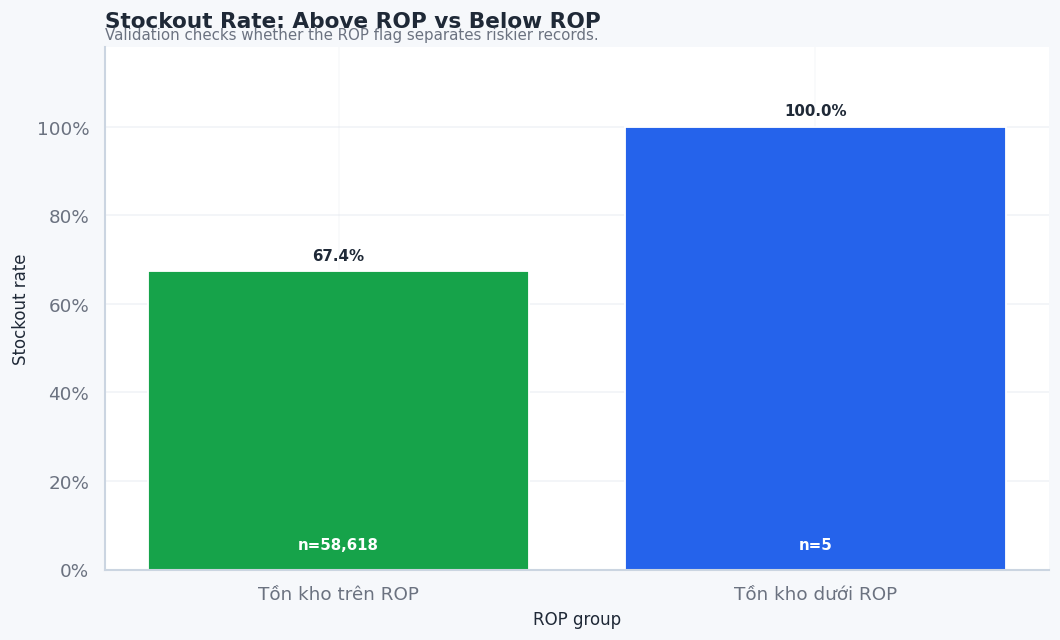

In [21]:
fig, ax = plt.subplots(figsize=(9, 5.5), facecolor=BACKGROUND)
plot_df = rop_validation.copy()
colors = plot_df['group'].map({'Tồn kho trên ROP': PALETTE['stable'], 'Tồn kho dưới ROP': PALETTE['stockout']})
ax.bar(plot_df['group'], plot_df['stockout_rate'], color=colors, edgecolor='white', linewidth=1.1)
clean_axis(
    ax,
    'Stockout Rate: Above ROP vs Below ROP',
    'ROP group',
    'Stockout rate',
    subtitle='Validation checks whether the ROP flag separates riskier records.'
)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
label_vbars(ax, fmt=lambda v: fmt_percent(v))
for idx, row in plot_df.reset_index(drop=True).iterrows():
    ax.text(idx, 0.04, f"n={fmt_number(row['records'])}", ha='center', va='bottom', fontsize=9, color='white', weight='bold')
plt.tight_layout()
plt.show()


In [22]:
rop_lookup = rop_validation.set_index('group')
above_rate = rop_lookup.loc['Tồn kho trên ROP', 'stockout_rate'] if 'Tồn kho trên ROP' in rop_lookup.index else np.nan
below_rate = rop_lookup.loc['Tồn kho dưới ROP', 'stockout_rate'] if 'Tồn kho dưới ROP' in rop_lookup.index else np.nan
below_lost = rop_lookup.loc['Tồn kho dưới ROP', 'lost_revenue'] if 'Tồn kho dưới ROP' in rop_lookup.index else np.nan
signal_gap = below_rate - above_rate

rop_signal_summary = pd.DataFrame({
    'Metric': [
        'Stockout rate above ROP',
        'Stockout rate below ROP',
        'Signal gap',
        'Lost revenue below ROP',
        'Validation read'
    ],
    'Value': [
        fmt_percent(above_rate),
        fmt_percent(below_rate),
        fmt_percent(signal_gap),
        fmt_currency(below_lost),
        'High precision but low coverage' if below_rate > above_rate else 'Weak separation'
    ]
})

display(rop_signal_summary)


,Metric,Value
0,Stockout rate above ROP,67.4%
1,Stockout rate below ROP,100.0%
2,Signal gap,32.6%
3,Lost revenue below ROP,173.6K
4,Validation read,High precision but low coverage


### Nhận xét kiểm định ROP

Nhóm nằm dưới điểm đặt hàng lại có tỷ lệ thiếu hàng **100.0%**, cao hơn nhóm còn lại (**67.4%**). Điều này cho thấy khi tín hiệu này báo động, rủi ro thiếu hàng thật sự cao.

Nhưng vấn đề là tín hiệu chỉ báo **5 bản ghi**. Trong khi tổng doanh thu bị mất do thiếu hàng là **799.9M**, nhóm bị ROP cảnh báo chỉ gắn với khoảng **173.6K** doanh thu bị mất. Như vậy, nếu chỉ dựa vào ROP, doanh nghiệp sẽ bỏ sót phần lớn vấn đề.

**Việc nên làm:** dùng ROP như cảnh báo đỏ cho trường hợp rất nặng, đồng thời bổ sung một bảng xếp hạng rủi ro rộng hơn cho toàn bộ mã sản phẩm.

**Kết luận:** ROP báo đúng khi nó báo, nhưng báo quá ít nên không thể là công cụ cảnh báo duy nhất.

## 10. [Predictive] Xếp hạng rủi ro thiếu hàng kỳ tới

Vì ROP chỉ bắt được rất ít trường hợp, phần này tạo thêm một danh sách dễ dùng hơn cho đội inventory: mã nào có nguy cơ thiếu hàng trong kỳ tới.

Điểm rủi ro được tính bằng cách kết hợp nhiều dấu hiệu dễ hiểu:

- Sản phẩm có hay thiếu hàng trong các tháng trước không?
- Nhu cầu gần đây có tăng so với bình thường không?
- Tỷ lệ đáp ứng đơn hàng gần đây có giảm không?
- Tồn kho hiện tại có đủ so với lượng bán gần nhất không?

Sau đó, sản phẩm được chia thành 4 nhóm: **Low, Medium, High, Critical**. Có thể hiểu `Critical` là nhóm cần kiểm tra ngay, còn `High` là nhóm cần đưa vào danh sách theo dõi sát.

In [23]:
risk_df = rop_df.sort_values(['product_id', 'snapshot_date']).copy()

risk_df['hist_stockout_rate_6m'] = (
    risk_df
    .groupby('product_id')['stockout_flag']
    .transform(lambda x: x.shift(1).rolling(6, min_periods=3).mean())
)

risk_df['avg_units_sold_6m'] = (
    risk_df
    .groupby('product_id')['units_sold']
    .transform(lambda x: x.shift(1).rolling(6, min_periods=3).mean())
)

risk_df['avg_fill_rate_3m'] = (
    risk_df
    .groupby('product_id')['fill_rate']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=2).mean())
)

risk_df['demand_pressure'] = np.where(
    risk_df['avg_units_sold_6m'] > 0,
    risk_df['units_sold'] / risk_df['avg_units_sold_6m'],
    np.nan
)

risk_df['fill_rate_gap'] = (1 - risk_df['avg_fill_rate_3m']).clip(lower=0)
risk_df['stock_cover_ratio'] = np.where(
    risk_df['units_sold'] > 0,
    risk_df['stock_on_hand'] / risk_df['units_sold'],
    np.nan
)
risk_df['stock_pressure'] = (1 - risk_df['stock_cover_ratio']).clip(lower=0, upper=1).fillna(0)

risk_snapshot_date = risk_df['snapshot_date'].max()
risk_latest = risk_df[risk_df['snapshot_date'] == risk_snapshot_date].copy()

# Scale components to 0-1 so the score is interpretable and robust to outliers.
risk_latest['stockout_component'] = risk_latest['hist_stockout_rate_6m'].fillna(risk_latest['stockout_flag'].mean()).clip(0, 1)
risk_latest['demand_component'] = ((risk_latest['demand_pressure'].fillna(1).clip(0, 2.5) - 1) / 1.5).clip(0, 1)
risk_latest['fill_component'] = (risk_latest['fill_rate_gap'].fillna(0).clip(0, 0.25) / 0.25).clip(0, 1)
risk_latest['stock_component'] = risk_latest['stock_pressure'].clip(0, 1)

risk_latest['stockout_risk_score'] = (
    0.40 * risk_latest['stockout_component'] +
    0.25 * risk_latest['demand_component'] +
    0.20 * risk_latest['fill_component'] +
    0.15 * risk_latest['stock_component']
)

risk_latest['stockout_risk_tier'] = pd.cut(
    risk_latest['stockout_risk_score'],
    bins=[-0.001, 0.25, 0.45, 0.65, 1.0],
    labels=['Low', 'Medium', 'High', 'Critical']
)

stockout_risk_tier = (
    risk_latest[[
        'snapshot_date',
        'product_id',
        'product_name',
        'category',
        'segment',
        'stock_on_hand',
        'units_sold',
        'hist_stockout_rate_6m',
        'demand_pressure',
        'avg_fill_rate_3m',
        'stock_cover_ratio',
        'stockout_risk_score',
        'stockout_risk_tier'
    ]]
    .sort_values('stockout_risk_score', ascending=False)
)

risk_tier_summary = (
    stockout_risk_tier
    .groupby('stockout_risk_tier', observed=False)
    .agg(
        products=('product_id', 'nunique'),
        avg_risk_score=('stockout_risk_score', 'mean'),
        avg_hist_stockout_rate=('hist_stockout_rate_6m', 'mean'),
        avg_demand_pressure=('demand_pressure', 'mean'),
        avg_fill_rate_3m=('avg_fill_rate_3m', 'mean'),
        median_stock_cover_ratio=('stock_cover_ratio', 'median')
    )
    .reset_index()
)

risk_tier_summary_display = risk_tier_summary.copy()
risk_tier_summary_display['avg_risk_score'] = risk_tier_summary_display['avg_risk_score'].map(lambda v: fmt_number(v, 2))
risk_tier_summary_display['avg_hist_stockout_rate'] = risk_tier_summary_display['avg_hist_stockout_rate'].map(fmt_percent)
risk_tier_summary_display['avg_demand_pressure'] = risk_tier_summary_display['avg_demand_pressure'].map(lambda v: fmt_number(v, 2))
risk_tier_summary_display['avg_fill_rate_3m'] = risk_tier_summary_display['avg_fill_rate_3m'].map(fmt_percent)
risk_tier_summary_display['median_stock_cover_ratio'] = risk_tier_summary_display['median_stock_cover_ratio'].map(lambda v: fmt_number(v, 2))

display(risk_tier_summary_display)
display(stockout_risk_tier.head(20))


,stockout_risk_tier,products,avg_risk_score,avg_hist_stockout_rate,avg_demand_pressure,avg_fill_rate_3m,median_stock_cover_ratio
0,Low,89,0.19,42.6%,0.58,98.1%,18.50
1,Medium,277,0.34,75.3%,0.71,96.3%,11.00
2,High,53,0.52,79.0%,2.40,93.9%,19.21
3,Critical,5,0.73,93.3%,2.87,85.6%,0.80


,snapshot_date,product_id,product_name,category,segment,stock_on_hand,units_sold,hist_stockout_rate_6m,demand_pressure,avg_fill_rate_3m,stock_cover_ratio,stockout_risk_score,stockout_risk_tier
12359,2022-12-31,668,SaigonFlex UC-33,Streetwear,Everyday,11,18,1.0000,2.2500,0.8222,0.6111,0.8089,Critical
28727,2022-12-31,1177,MekongFit UE-13,Streetwear,Performance,41,67,0.6667,2.3647,0.6222,0.6119,0.7523,Critical
28723,2022-12-31,1176,MekongFit UE-12,Streetwear,Performance,4,5,1.0000,3.0000,0.9556,0.8000,0.7155,Critical
15313,2022-12-31,762,HanoiStreet RP-50,Outdoor,Activewear,1221,13,1.0000,2.6000,0.9333,93.9231,0.7034,Critical
53091,2022-12-31,2207,VietMotion RP-04,Outdoor,Activewear,351,59,1.0000,4.1163,0.9444,5.9492,0.6945,Critical
9556,2022-12-31,570,SaigonFlex UC-35,Streetwear,Everyday,49,9,0.8333,3.6000,0.9333,5.4444,0.6367,High
38430,2022-12-31,1657,VietMode RS-95,Outdoor,Premium,12,6,1.0000,2.1429,0.9444,2.0000,0.6349,High
25145,2022-12-31,1085,MekongFit RP-31,Outdoor,Activewear,1390,62,0.8333,3.6117,0.9444,22.4194,0.6278,High
54638,2022-12-31,2238,VietMotion RP-35,Outdoor,Activewear,444,4,0.8333,3.4286,0.9444,111.0000,0.6278,High
54018,2022-12-31,2224,VietMotion RP-21,Outdoor,Activewear,796,75,0.8333,3.8462,0.9444,10.6133,0.6278,High


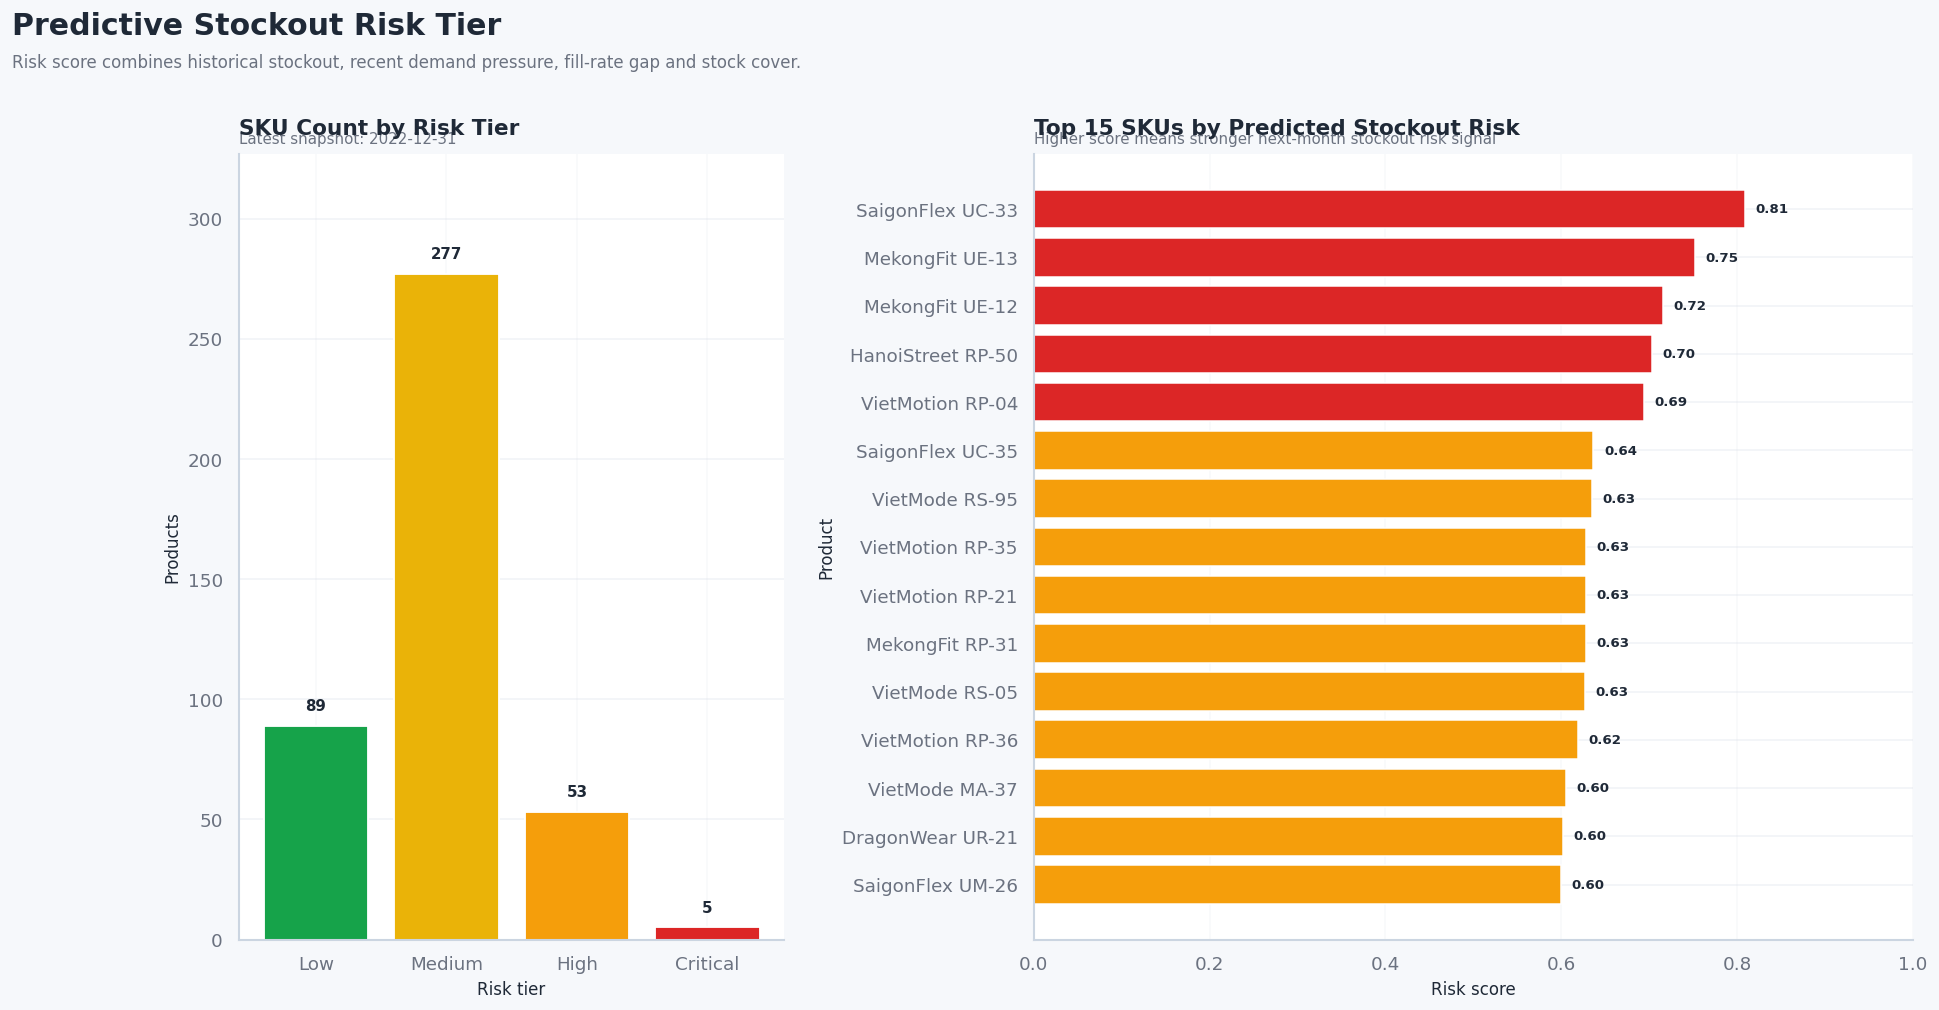

In [24]:
fig = plt.figure(figsize=(18, 8.5), facecolor=BACKGROUND)
gs = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[0.9, 1.45], wspace=0.35)
fig.suptitle('Predictive Stockout Risk Tier', fontsize=18, fontweight='bold', color=TEXT, x=0.02, ha='left', y=1.02)
fig.text(0.02, 0.965, 'Risk score combines historical stockout, recent demand pressure, fill-rate gap and stock cover.', fontsize=10, color=MUTED)

ax_tier = fig.add_subplot(gs[0, 0])
tier_order = ['Low', 'Medium', 'High', 'Critical']
tier_colors = {'Low': PALETTE['stable'], 'Medium': PALETTE['warning'], 'High': PALETTE['overstock'], 'Critical': PALETTE['volatile']}
tier_counts = stockout_risk_tier['stockout_risk_tier'].value_counts().reindex(tier_order).fillna(0)
ax_tier.bar(tier_counts.index.astype(str), tier_counts.values, color=[tier_colors[t] for t in tier_order], edgecolor='white', linewidth=1.1)
clean_axis(ax_tier, 'SKU Count by Risk Tier', 'Risk tier', 'Products', subtitle=f'Latest snapshot: {risk_snapshot_date:%Y-%m-%d}')
label_vbars(ax_tier, fmt=lambda v: fmt_number(v))

ax_top = fig.add_subplot(gs[0, 1])
top_risk = stockout_risk_tier.head(15).sort_values('stockout_risk_score', ascending=True)
colors = top_risk['stockout_risk_tier'].astype(str).map(tier_colors)
ax_top.barh(top_risk['product_name'], top_risk['stockout_risk_score'], color=colors, edgecolor='white', linewidth=0.9)
clean_axis(ax_top, 'Top 15 SKUs by Predicted Stockout Risk', 'Risk score', 'Product', subtitle='Higher score means stronger next-month stockout risk signal')
ax_top.set_xlim(0, 1)
label_hbars(ax_top, fmt=lambda v: fmt_number(v, 2), fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


### Nhận xét về nhóm rủi ro thiếu hàng

Ở snapshot mới nhất, có **5 mã sản phẩm** thuộc nhóm `Critical` và **53 mã** thuộc nhóm `High`. Đây là các mã có nhiều dấu hiệu xấu cùng lúc: từng thiếu hàng nhiều, nhu cầu gần đây cao, tỷ lệ đáp ứng đơn hàng không tốt hoặc tồn kho chưa đủ so với lượng bán.

Điểm mạnh của phần này là nó không chờ đến khi sản phẩm đã thiếu hàng mới phản ứng. Nó tạo ra danh sách để đội inventory kiểm tra trước kỳ bán tiếp theo.

**Việc nên làm:** với nhóm `Critical`, kiểm tra ngay tồn kho thực tế, đơn hàng nhập sắp về, kế hoạch khuyến mãi và cách phân bổ hàng. Với nhóm `High`, đưa vào danh sách theo dõi định kỳ.

**Kết luận:** Bảng xếp hạng rủi ro giúp doanh nghiệp chủ động phòng thiếu hàng thay vì chỉ xử lý sau khi đã mất doanh thu.

## 11. [Prescriptive] Ưu tiên mã sản phẩm cần xử lý trước

Sau khi biết mã nào có rủi ro, câu hỏi tiếp theo là: nếu chỉ có thời gian và nguồn lực xử lý một phần danh mục, nên bắt đầu từ đâu?

Phần này tạo **điểm ưu tiên** cho từng mã sản phẩm. Điểm này kết hợp ba yếu tố:

- Doanh thu bị mất do thiếu hàng.
- Biên lợi nhuận của sản phẩm.
- Tần suất thiếu hàng.

Nói đơn giản, sản phẩm có điểm cao là sản phẩm vừa gây mất tiền, vừa có lợi nhuận tốt, vừa thường xuyên thiếu hàng.

In [25]:
product_priority = (
    inv_lost
    .groupby(['product_id', 'product_name', 'category', 'segment'])
    .agg(
        lost_revenue=('lost_revenue_est', 'sum'),
        lost_margin=('lost_margin_est', 'sum'),
        stockout_days=('stockout_days', 'sum'),
        stockout_rate=('stockout_flag', 'mean'),
        avg_margin_rate=('gross_margin_rate', 'mean'),
        avg_fill_rate=('fill_rate', 'mean'),
        avg_days_of_supply=('days_of_supply', 'mean'),
        total_units_sold=('units_sold', 'sum')
    )
    .reset_index()
)

product_priority['priority_score'] = (
    product_priority['lost_revenue'] *
    product_priority['avg_margin_rate'].fillna(0) *
    (1 + product_priority['stockout_rate'])
)

product_priority['priority_score_adjusted'] = (
    product_priority['lost_revenue'] *
    product_priority['avg_margin_rate'].fillna(0) *
    (1 + product_priority['stockout_rate']) /
    (1 + np.log1p(product_priority['avg_days_of_supply'].clip(lower=0)))
)

product_priority = product_priority.sort_values('priority_score', ascending=False)
display(product_priority.head(20))
product_priority.to_csv(OUTPUT_DIR / 'product_priority.csv', index=False)


,product_id,product_name,category,segment,lost_revenue,lost_margin,stockout_days,stockout_rate,avg_margin_rate,avg_fill_rate,avg_days_of_supply,total_units_sold,priority_score,priority_score_adjusted
279,438,SaigonFlex UM-43,Streetwear,Balanced,"12,402,112.1775","5,331,668.0251",174,0.7073,0.4299,0.9293,"4,786.4707",9124,"9,102,847.8478","960,848.7264"
1403,2045,UrbanVN UE-05,Streetwear,Performance,"9,332,562.3487","4,311,643.8051",116,0.6240,0.4620,0.9691,"2,250.2632",10376,"7,002,109.5395","803,063.5825"
418,604,SaigonFlex UC-69,Streetwear,Everyday,"10,681,555.2641","3,470,437.3053",132,0.7143,0.3249,0.9651,"2,493.0508",10506,"5,949,321.0948","674,399.0065"
315,487,SaigonFlex UM-92,Streetwear,Balanced,"19,052,306.0484","2,915,002.8254",82,0.6667,0.1530,0.9620,"4,083.8167",9623,"4,858,338.0423","521,558.9143"
282,443,SaigonFlex UM-48,Streetwear,Balanced,"5,550,075.5740","2,376,542.3608",117,0.6810,0.4282,0.9664,"1,493.9698",3541,"3,995,049.6582","480,760.0888"
275,433,SaigonFlex UM-38,Streetwear,Balanced,"5,034,458.3180","2,159,782.6184",104,0.6789,0.4290,0.9682,"1,348.5706",3163,"3,626,057.0566","441,795.7477"
1570,2332,VietMotion UE-06,Streetwear,Performance,"9,617,718.0092","2,064,924.0566",121,0.6349,0.2147,0.9680,"1,079.3452",9386,"3,375,986.9497","422,789.1994"
305,475,SaigonFlex UM-80,Streetwear,Balanced,"8,698,297.6790","1,770,103.5777",52,0.5714,0.2035,0.9725,"6,547.9270",6434,"2,781,591.3364","284,211.2271"
412,596,SaigonFlex UC-61,Streetwear,Everyday,"4,068,691.2795","1,586,789.5990",116,0.7327,0.3900,0.9617,"3,122.8356",2425,"2,749,387.9190","303,906.6613"
637,966,HanoiStreet UC-29,Streetwear,Everyday,"3,815,664.8024","1,644,551.5298",104,0.6634,0.4310,0.9657,"2,947.6040",3307,"2,735,491.6536","304,312.5094"


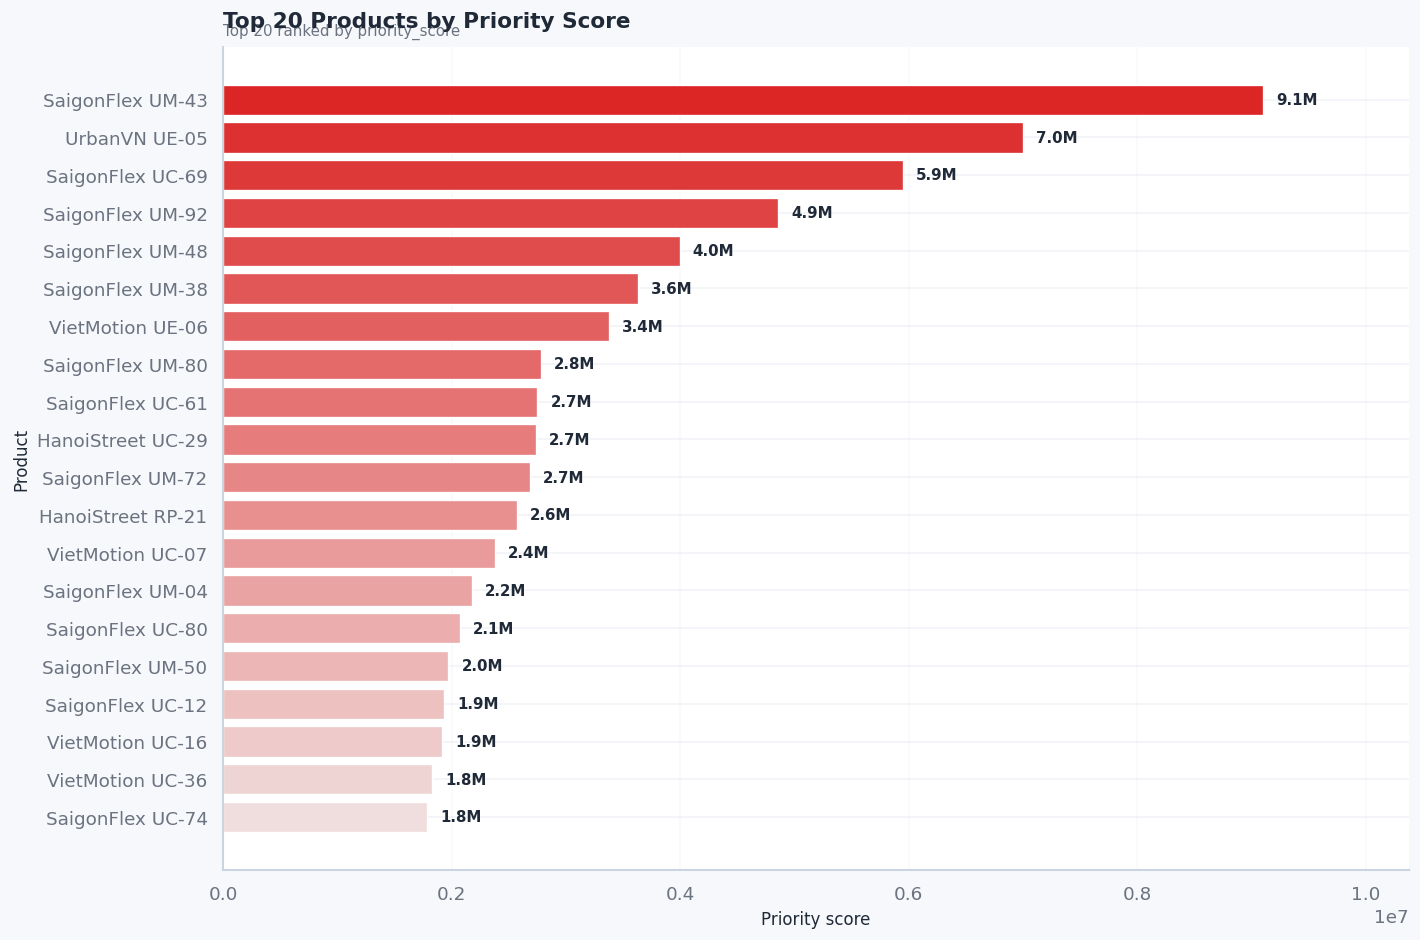

In [26]:
top_n_barh(
    product_priority,
    x='priority_score',
    y='product_name',
    title='Top 20 Products by Priority Score',
    xlabel='Priority score',
    ylabel='Product',
    n=20,
    color=PALETTE['volatile'],
    value_format=lambda v: fmt_currency(v, 1),
    figsize=(12, 8)
)


In [27]:
top_priority = product_priority.iloc[0]
top_priority_10_lost = product_priority.head(10)['lost_revenue'].sum()
share_top10_lost = top_priority_10_lost / total_lost_revenue if total_lost_revenue else np.nan

priority_takeaways = pd.DataFrame({
    'Metric': [
        'Top priority SKU',
        'Top SKU priority score',
        'Top SKU lost revenue',
        'Top SKU stockout rate',
        'Top SKU margin rate',
        'Top 10 lost revenue share'
    ],
    'Value': [
        top_priority['product_name'],
        fmt_currency(top_priority['priority_score']),
        fmt_currency(top_priority['lost_revenue']),
        fmt_percent(top_priority['stockout_rate']),
        fmt_percent(top_priority['avg_margin_rate']),
        fmt_percent(share_top10_lost)
    ]
})

display(priority_takeaways)


,Metric,Value
0,Top priority SKU,SaigonFlex UM-43
1,Top SKU priority score,9.1M
2,Top SKU lost revenue,12.4M
3,Top SKU stockout rate,70.7%
4,Top SKU margin rate,43.0%
5,Top 10 lost revenue share,11.0%


### Nhận xét về danh sách ưu tiên sản phẩm

Mã đứng đầu danh sách là **SaigonFlex UM-43**. Mã này có doanh thu bị mất **12.4M**, tỷ lệ thiếu hàng **70.7%** và margin **43.0%**. Đây là kiểu sản phẩm rất đáng kiểm tra vì nếu xử lý tốt, doanh nghiệp có thể thu hồi cả doanh thu lẫn lợi nhuận.

Tuy nhiên, top 10 mã chỉ chiếm **11.0%** tổng doanh thu bị mất. Điều này cho thấy vấn đề không nằm ở vài mã đơn lẻ, mà là một nhóm sản phẩm rộng hơn.

Một điểm cần cẩn trọng: nếu một mã có điểm ưu tiên cao nhưng số ngày tồn kho cũng cao, không nên tự động nhập thêm. Khi đó cần kiểm tra xem hàng có đang nằm sai thời điểm, sai kênh hoặc sai biến thể không.

**Kết luận:** Danh sách ưu tiên giúp biết nên kiểm tra mã nào trước, nhưng quyết định nhập thêm hay giảm hàng vẫn cần xem bối cảnh tồn kho của từng mã.

## 12. [Prescriptive] Kịch bản thu hồi doanh thu

Phần này biến đề xuất cải thiện tồn kho thành một bài toán lợi ích - chi phí.

Thay vì nói chung chung “giảm thiếu hàng sẽ tốt hơn”, notebook ước tính nếu giảm thiếu hàng 10%, 20%, 30% hoặc 40% thì doanh nghiệp có thể thu hồi bao nhiêu doanh thu và lợi nhuận gộp.

Điều này giúp stakeholder so sánh: lợi ích thu hồi được có đủ lớn để bù cho chi phí tăng tồn kho, vận chuyển, lưu kho hoặc giảm giá xả hàng hay không.

In [28]:
scenario_stockout = pd.DataFrame({'Mức giảm stockout giả định': [0.10, 0.20, 0.30, 0.40]})
scenario_stockout['Recovered revenue estimate'] = total_lost_revenue * scenario_stockout['Mức giảm stockout giả định']
scenario_stockout['Recovered gross margin estimate'] = total_lost_margin * scenario_stockout['Mức giảm stockout giả định']
display(scenario_stockout)


,Mức giảm stockout giả định,Recovered revenue estimate,Recovered gross margin estimate
0,0.1000,"79,987,348.3238","16,187,844.8669"
1,0.2000,"159,974,696.6477","32,375,689.7338"
2,0.3000,"239,962,044.9715","48,563,534.6008"
3,0.4000,"319,949,393.2954","64,751,379.4677"


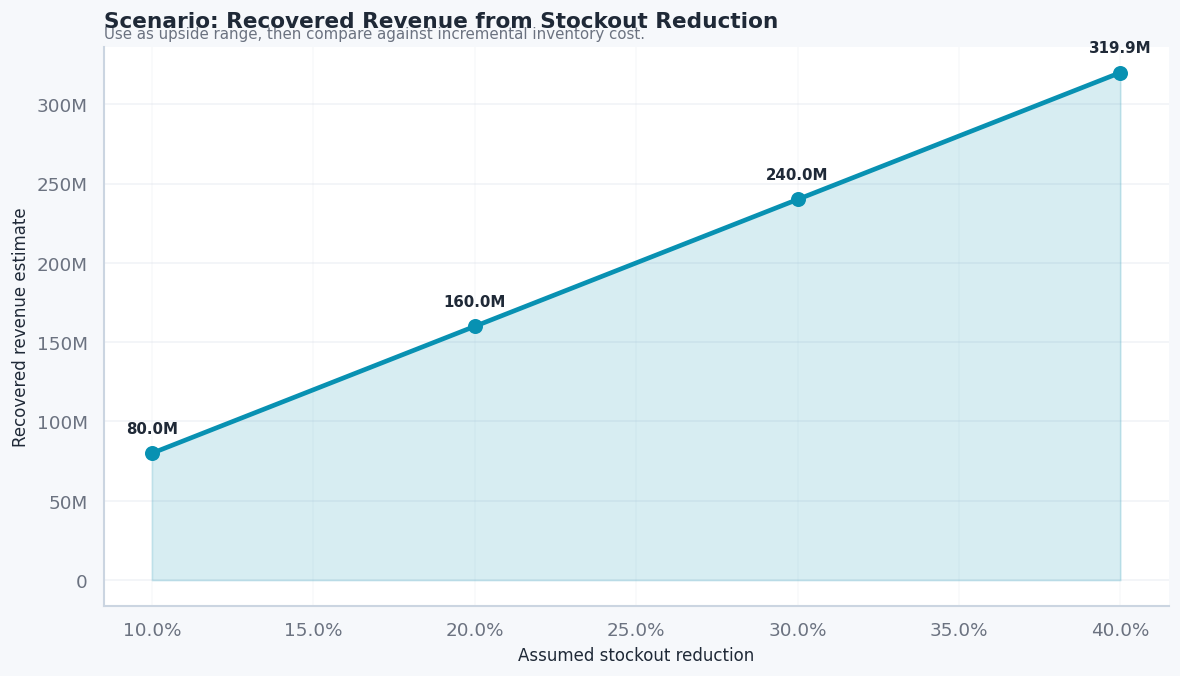

In [29]:
fig, ax = plt.subplots(figsize=(10, 5.8), facecolor=BACKGROUND)
plot_df = scenario_stockout.copy()
ax.plot(
    plot_df['Mức giảm stockout giả định'],
    plot_df['Recovered revenue estimate'],
    marker='o',
    linewidth=2.8,
    markersize=8,
    color=PALETTE['accent']
)
ax.fill_between(
    plot_df['Mức giảm stockout giả định'],
    plot_df['Recovered revenue estimate'],
    color=PALETTE['accent'],
    alpha=0.16
)
for _, row in plot_df.iterrows():
    ax.annotate(
        fmt_currency(row['Recovered revenue estimate'], 1),
        (row['Mức giảm stockout giả định'], row['Recovered revenue estimate']),
        xytext=(0, 12),
        textcoords='offset points',
        ha='center',
        fontsize=9,
        weight='bold',
        color=TEXT
    )
clean_axis(
    ax,
    'Scenario: Recovered Revenue from Stockout Reduction',
    'Assumed stockout reduction',
    'Recovered revenue estimate',
    subtitle='Use as upside range, then compare against incremental inventory cost.'
)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: fmt_currency(x, 0)))
plt.tight_layout()
plt.show()


In [30]:
scenario_20 = scenario_stockout.loc[scenario_stockout['Mức giảm stockout giả định'] == 0.20].iloc[0]
scenario_40 = scenario_stockout.loc[scenario_stockout['Mức giảm stockout giả định'] == 0.40].iloc[0]

scenario_takeaways = pd.DataFrame({
    'Scenario': ['20% stockout reduction', '40% stockout reduction'],
    'Recovered revenue': [
        fmt_currency(scenario_20['Recovered revenue estimate']),
        fmt_currency(scenario_40['Recovered revenue estimate'])
    ],
    'Recovered gross margin': [
        fmt_currency(scenario_20['Recovered gross margin estimate']),
        fmt_currency(scenario_40['Recovered gross margin estimate'])
    ],
    'Use case': [
        'Base case for pilot business case',
        'Upside case if intervention scales successfully'
    ]
})

display(scenario_takeaways)


,Scenario,Recovered revenue,Recovered gross margin,Use case
0,20% stockout reduction,160.0M,32.4M,Base case for pilot business case
1,40% stockout reduction,319.9M,64.8M,Upside case if intervention scales successfully


### Nhận xét về kịch bản tài chính

Nếu giảm thiếu hàng **20%**, doanh nghiệp có thể thu hồi khoảng **160.0M doanh thu** và **32.4M lợi nhuận gộp**. Nếu giảm **40%**, doanh thu có thể phục hồi khoảng **319.9M**.

Nhưng không nên hiểu rằng giảm thiếu hàng bằng mọi giá là tốt. Nếu để giảm thiếu hàng mà phải nhập thêm quá nhiều, làm tăng chi phí lưu kho hoặc tạo thêm dư hàng, lợi nhuận thực tế có thể không cải thiện.

**Việc nên làm:** dùng kịch bản 20% làm pilot ban đầu trên nhóm sản phẩm ưu tiên. Sau khi đo hiệu quả thực tế, mới quyết định mở rộng.

**Kết luận:** Giảm thiếu hàng nên được triển khai như một thử nghiệm có đo lợi ích - chi phí, không phải tăng tồn kho trên diện rộng.

## 13. [Prescriptive] Khuyến nghị theo nhóm tồn kho

Phần này là nơi chuyển toàn bộ phân tích thành hành động.

Điểm quan trọng nhất: các nhóm sản phẩm khác nhau cần cách xử lý khác nhau. Nếu một mã thường xuyên thiếu hàng, có thể cần tăng tồn an toàn. Nếu một mã đang dư hàng, cần giảm nhập hoặc xả hàng. Nếu một mã vừa thiếu vừa dư, cần kiểm tra lại cách dự báo và thời điểm nhập.

Mục tiêu là tạo một playbook đơn giản để đội inventory biết nên làm gì với từng nhóm sản phẩm.

In [31]:
tradeoff_by_group = (
    matrix_df
    .groupby('inventory_group')
    .agg(
        products=('product_id', 'nunique'),
        avg_stockout_rate=('stockout_rate', 'mean'),
        avg_overstock_rate=('overstock_rate', 'mean'),
        total_lost_revenue=('lost_revenue', 'sum'),
        avg_inventory_value=('inventory_value', 'mean'),
        total_units_sold=('total_units_sold', 'sum')
    )
    .reset_index()
    .sort_values('total_lost_revenue', ascending=False)
)

action_map = {
    'Thiếu hàng thường xuyên': 'Tăng Dynamic ROP, safety stock và kiểm tra lead time',
    'Dư hàng': 'Giảm replenishment, markdown hoặc bundle để giải phóng vốn',
    'Tồn kho biến động': 'Rà soát forecast, replenishment cycle và allocation theo kênh/kho',
    'Ổn định': 'Giữ policy hiện tại, theo dõi dashboard định kỳ'
}
tradeoff_by_group['recommended_action'] = tradeoff_by_group['inventory_group'].map(action_map)

display(tradeoff_by_group)
tradeoff_by_group.to_csv(OUTPUT_DIR / 'tradeoff_by_group.csv', index=False)


,inventory_group,products,avg_stockout_rate,avg_overstock_rate,total_lost_revenue,avg_inventory_value,total_units_sold,recommended_action
0,Dư hàng,452,0.6155,0.8717,"397,886,244.4781","735,891.9541",500869,"Giảm replenishment, markdown hoặc bundle để gi..."
2,Tồn kho biến động,360,0.7416,0.8671,"290,237,998.0219","579,916.8401",343573,"Rà soát forecast, replenishment cycle và alloc..."
1,Thiếu hàng thường xuyên,449,0.8336,0.2315,"71,012,278.4795","89,259.8724",47981,"Tăng Dynamic ROP, safety stock và kiểm tra lea..."
3,Ổn định,363,0.5111,0.2562,"40,736,962.2589","89,398.1913",36451,"Giữ policy hiện tại, theo dõi dashboard định kỳ"


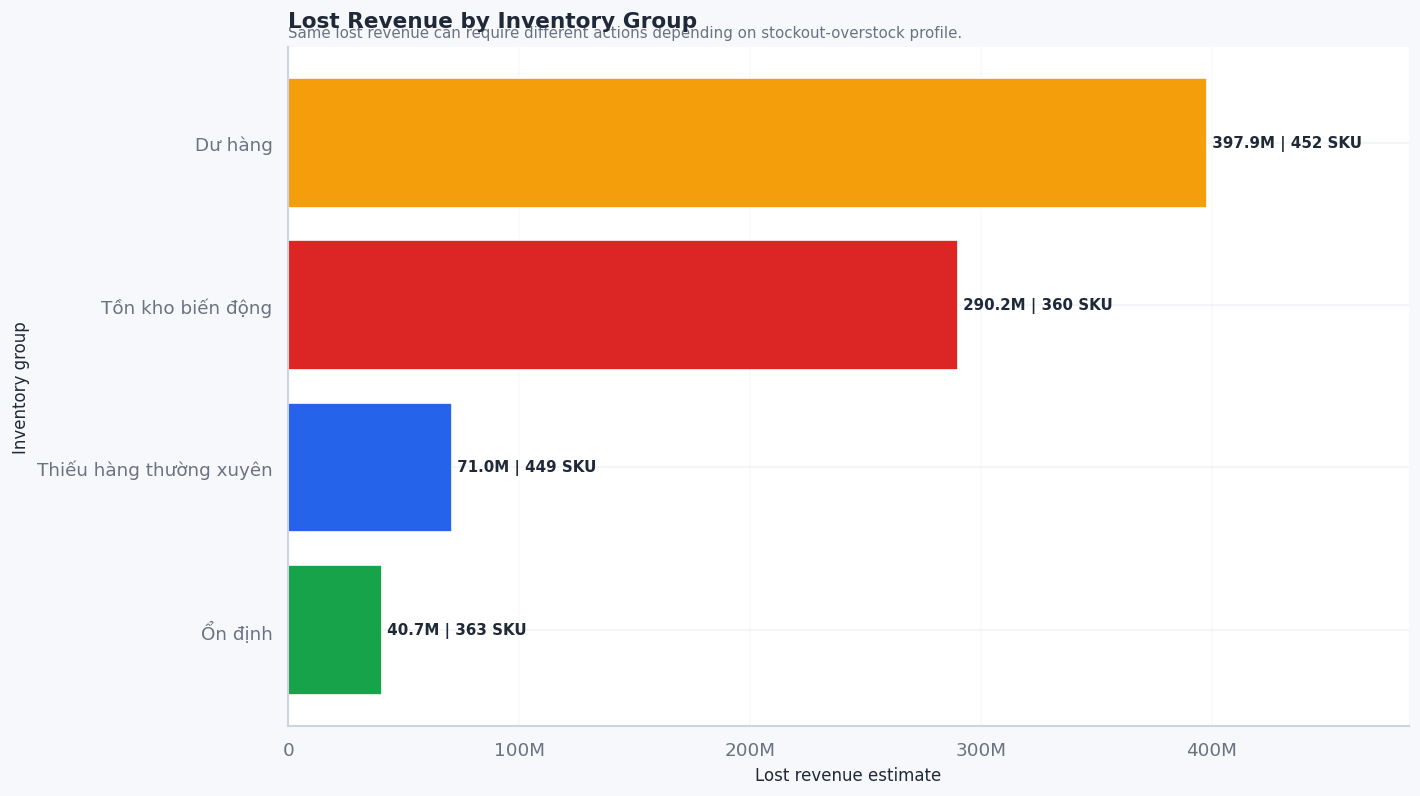

In [32]:
fig, ax = plt.subplots(figsize=(12, 6.8), facecolor=BACKGROUND)
plot_df = tradeoff_by_group.sort_values('total_lost_revenue', ascending=True).copy()
colors = plot_df['inventory_group'].map(GROUP_COLORS)
ax.barh(plot_df['inventory_group'], plot_df['total_lost_revenue'], color=colors, edgecolor='white', linewidth=1.0)
clean_axis(
    ax,
    'Lost Revenue by Inventory Group',
    'Lost revenue estimate',
    'Inventory group',
    subtitle='Same lost revenue can require different actions depending on stockout-overstock profile.'
)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: fmt_currency(x, 0)))
ax.margins(x=0.22)
for patch, (_, row) in zip(ax.patches, plot_df.iterrows()):
    label = f" {fmt_currency(row['total_lost_revenue'])} | {fmt_number(row['products'])} SKU"
    ax.text(patch.get_width(), patch.get_y() + patch.get_height() / 2, label, va='center', ha='left', fontsize=9, color=TEXT, weight='bold')
plt.tight_layout()
plt.show()


In [33]:
top_tradeoff_group = tradeoff_by_group.iloc[0]

tradeoff_action_summary = tradeoff_by_group[[
    'inventory_group',
    'products',
    'avg_stockout_rate',
    'avg_overstock_rate',
    'total_lost_revenue',
    'recommended_action'
]].copy()
tradeoff_action_summary['avg_stockout_rate'] = tradeoff_action_summary['avg_stockout_rate'].map(fmt_percent)
tradeoff_action_summary['avg_overstock_rate'] = tradeoff_action_summary['avg_overstock_rate'].map(fmt_percent)
tradeoff_action_summary['total_lost_revenue'] = tradeoff_action_summary['total_lost_revenue'].map(fmt_currency)

display(tradeoff_action_summary)


,inventory_group,products,avg_stockout_rate,avg_overstock_rate,total_lost_revenue,recommended_action
0,Dư hàng,452,61.6%,87.2%,397.9M,"Giảm replenishment, markdown hoặc bundle để gi..."
2,Tồn kho biến động,360,74.2%,86.7%,290.2M,"Rà soát forecast, replenishment cycle và alloc..."
1,Thiếu hàng thường xuyên,449,83.4%,23.1%,71.0M,"Tăng Dynamic ROP, safety stock và kiểm tra lea..."
3,Ổn định,363,51.1%,25.6%,40.7M,"Giữ policy hiện tại, theo dõi dashboard định kỳ"


### Nhận xét và khuyến nghị hành động

Nhóm tạo doanh thu bị mất lớn nhất lại là nhóm **Dư hàng**, với **397.9M** trên **452 mã sản phẩm**. Điều này cho thấy không thể nhìn “dư hàng” một cách đơn giản. Một mã có thể dư ở một số tháng nhưng vẫn thiếu vào thời điểm nhu cầu tăng.

Nếu công ty nhập thêm hàng cho cả nhóm này, vốn bị khóa có thể tăng. Nhưng nếu markdown toàn bộ nhóm này, công ty có thể xả nhầm cả những mã vẫn còn nhu cầu.

**Việc nên làm:** xử lý theo nhóm nguyên nhân:

- Nhóm thiếu hàng thường xuyên: tăng tồn an toàn có kiểm soát.
- Nhóm dư hàng: giảm nhập hoặc xả hàng có chọn lọc.
- Nhóm biến động: xem lại dự báo, lịch nhập và phân bổ hàng.
- Nhóm ổn định: giữ chính sách hiện tại và theo dõi.

**Kết luận:** Cách làm đúng không phải một chính sách chung, mà là hành động khác nhau cho từng nhóm tồn kho.

## 14. [Executive Summary] Tóm tắt cho báo cáo

Phần này gom toàn bộ câu chuyện thành bản tóm tắt cho stakeholder.

Nếu chỉ có thời gian đọc một phần, hãy đọc phần này. Nó trả lời trực tiếp:

- Vấn đề tồn kho chính là gì?
- Vấn đề nằm ở nhóm nào?
- Mã nào có rủi ro sắp tới?
- Doanh nghiệp nên xử lý như thế nào?
- Cơ hội tài chính nếu cải thiện là bao nhiêu?

Mục tiêu là giúp người đọc hiểu logic kinh doanh mà không cần xem code.

In [34]:
final_summary = pd.DataFrame({
    'Cấp độ': ['Descriptive - Chuyện gì xảy ra?', 'Diagnostic - Vì sao xảy ra?', 'Predictive - Điều gì có thể xảy ra?', 'Prescriptive - Nên làm gì?'],
    'Phần trong notebook': [
        'KPI + distributions',
        'Category/segment/lost revenue/overstock/matrix',
        'Demand estimate + dynamic ROP + validation + risk tier',
        'Priority score + scenario + trade-off + recommendations'
    ],
    'Thông điệp chính': [
        f'Stockout rate {fmt_percent(stockout_rate)}, overstock rate {fmt_percent(overstock_rate)}, fill rate {fmt_percent(fill_rate_avg)}.',
        f'Lost revenue estimated at {fmt_currency(total_lost_revenue)}; top lost category is {top_lost_cat["category"]}.',
        f'Below-ROP group stockout rate is {fmt_percent(below_rate)} vs above-ROP {fmt_percent(above_rate)}.',
        f'Top priority SKU is {top_priority["product_name"]}; 20% stockout reduction could recover {fmt_currency(scenario_20["Recovered revenue estimate"])} revenue.'
    ],
    'Ý nghĩa kinh doanh': [
        'Không nên chỉ tăng tồn kho; cần xử lý cả thiếu hàng và dư hàng.',
        'Doanh thu bị mất tập trung đủ rõ để ưu tiên theo category và mã sản phẩm.',
        'ROP là cảnh báo đỏ; risk tier là watchlist rộng hơn cho tháng tới.',
        'Mỗi nhóm tồn kho cần hành động khác nhau, không dùng một chính sách chung.'
    ]
})

display(final_summary)

export_checks = pd.DataFrame({
    'file': ['inventory_kpi.csv', 'lost_by_category.csv', 'product_priority.csv', 'rop_validation.csv', 'tradeoff_by_group.csv']
})
export_checks['path'] = export_checks['file'].apply(lambda f: str(OUTPUT_DIR / f))
export_checks['exists'] = export_checks['file'].apply(lambda f: (OUTPUT_DIR / f).exists())
export_checks['rows'] = export_checks['file'].apply(lambda f: len(pd.read_csv(OUTPUT_DIR / f)) if (OUTPUT_DIR / f).exists() else 0)
display(export_checks)


,Cấp độ,Phần trong notebook,Thông điệp chính,Ý nghĩa kinh doanh
0,Descriptive - Chuyện gì xảy ra?,KPI + distributions,"Stockout rate 67.3%, overstock rate 76.3%, fil...",Không nên chỉ tăng tồn kho; cần xử lý cả thiếu...
1,Diagnostic - Vì sao xảy ra?,Category/segment/lost revenue/overstock/matrix,Lost revenue estimated at 799.9M; top lost cat...,Doanh thu bị mất tập trung đủ rõ để ưu tiên th...
2,Predictive - Điều gì có thể xảy ra?,Demand estimate + dynamic ROP + validation + r...,Below-ROP group stockout rate is 100.0% vs abo...,ROP là cảnh báo đỏ; risk tier là watchlist rộn...
3,Prescriptive - Nên làm gì?,Priority score + scenario + trade-off + recomm...,Top priority SKU is SaigonFlex UM-43; 20% stoc...,"Mỗi nhóm tồn kho cần hành động khác nhau, khôn..."


,file,path,exists,rows
0,inventory_kpi.csv,/home/ductien/Documents/DATATHON_2026/outputs/...,True,10
1,lost_by_category.csv,/home/ductien/Documents/DATATHON_2026/outputs/...,True,4
2,product_priority.csv,/home/ductien/Documents/DATATHON_2026/outputs/...,True,1624
3,rop_validation.csv,/home/ductien/Documents/DATATHON_2026/outputs/...,True,2
4,tradeoff_by_group.csv,/home/ductien/Documents/DATATHON_2026/outputs/...,True,4


### Tóm tắt kinh doanh cuối cùng

**1. Hiện trạng.** Doanh nghiệp đang vừa thiếu hàng vừa dư hàng: tỷ lệ thiếu hàng **67.3%**, tỷ lệ dư hàng **76.3%**, trong khi tỷ lệ đáp ứng đơn hàng vẫn **96.1%**. Điều này cho thấy vấn đề không phải thiếu hàng toàn hệ thống, mà là hàng tồn chưa được đặt đúng mã sản phẩm và đúng thời điểm.

**2. Nguyên nhân chính.** Thiếu hàng làm mất ước tính **799.9M doanh thu** và **161.9M lợi nhuận gộp**. Riêng **Streetwear** chiếm **80.3%** doanh thu bị mất, đồng thời cũng là nhóm khóa vốn lớn nhất do dư hàng. Đây là dấu hiệu rõ của việc sai cơ cấu tồn kho.

**3. Rủi ro sắp tới.** Điểm đặt hàng lại có thể dùng như cảnh báo đỏ cho trường hợp rất nghiêm trọng, nhưng chưa đủ bao phủ toàn bộ vấn đề. Vì vậy notebook bổ sung bảng xếp hạng rủi ro thiếu hàng để tạo danh sách theo dõi cho kỳ tới, đặc biệt là nhóm `Critical` và `High`.

**4. Hành động đề xuất.** Bắt đầu với các mã có điểm ưu tiên cao như **SaigonFlex UM-43**, nhưng không nhập thêm hàng một cách máy móc. Cần kiểm tra từng mã theo nhóm: mã thiếu hàng thì tăng tồn an toàn, mã dư hàng thì giảm nhập/xả hàng, mã biến động thì xem lại dự báo và phân bổ.

**5. Cơ hội tài chính.** Nếu giảm thiếu hàng **20%**, doanh nghiệp có thể thu hồi khoảng **160.0M doanh thu** và **32.4M lợi nhuận gộp**. Đây là mức hợp lý để thử nghiệm pilot trước khi mở rộng.

**Kết luận cho sếp:** Cơ hội không nằm ở việc tăng tồn kho toàn bộ danh mục, mà nằm ở việc **tái phân bổ hàng tồn đúng mã sản phẩm, đúng thời điểm, theo mức độ ưu tiên tài chính**.

## 15. [Report-ready] Tổng kết theo flow chuẩn cho báo cáo

### 1. Bối cảnh kinh doanh

Doanh nghiệp đang gặp một bài toán tồn kho hai chiều: vừa có nhiều thời điểm thiếu hàng, vừa có nhiều hàng đang dư trong kho. Điều này đặc biệt quan trọng trong ngành thời trang, nơi nhu cầu thay đổi nhanh và sản phẩm dễ lỗi mùa hoặc lỗi xu hướng nếu tồn quá lâu.

Mục tiêu của phân tích không phải là đề xuất nhập thêm hàng cho toàn bộ danh mục. Mục tiêu đúng hơn là tìm cách **đưa hàng về đúng mã sản phẩm, đúng thời điểm và đúng mức nhu cầu**.

### 2. Hiện trạng chính

Dữ liệu cho thấy tỷ lệ thiếu hàng đạt **67.3%**, tỷ lệ dư hàng đạt **76.3%**, trong khi tỷ lệ đáp ứng đơn hàng trung bình vẫn ở mức **96.1%**. Đây là một nghịch lý quan trọng: hệ thống không phải hoàn toàn thiếu hàng, nhưng vẫn có nhiều điểm thiếu hàng cục bộ.

Điều này cho thấy vấn đề lớn nhất không nằm ở tổng lượng hàng, mà nằm ở cách phân bổ hàng theo mã sản phẩm và theo thời điểm.

### 3. Nguyên nhân và tác động tài chính

Thiếu hàng làm mất ước tính **151,803 sản phẩm bán ra**, tương đương khoảng **799.9M doanh thu** và **161.9M lợi nhuận gộp**. Trong đó, **Streetwear** là nhóm chịu tác động lớn nhất, chiếm **80.3%** tổng doanh thu bị mất.

Tuy nhiên, Streetwear cũng là nhóm khóa vốn nhiều nhất do dư hàng. Điều này cho thấy vấn đề không phải là Streetwear cần nhiều hàng hơn nói chung, mà là Streetwear cần đúng cơ cấu hàng hơn: mã bán tốt cần được bổ sung, mã bán chậm cần được giảm nhập hoặc xả hàng.

### 4. Phân loại vấn đề tồn kho

Ma trận thiếu hàng - dư hàng chia danh mục thành 4 nhóm hành động:

- **Thiếu hàng thường xuyên:** cần tăng tồn an toàn hoặc bổ sung hàng nhanh hơn.
- **Dư hàng:** cần giảm nhập, bundle hoặc markdown có chọn lọc.
- **Tồn kho biến động:** cần xem lại dự báo, lịch nhập hàng và phân bổ hàng.
- **Ổn định:** tiếp tục theo dõi, chưa cần can thiệp mạnh.

Điểm quan trọng là nhóm **Dư hàng** lại tạo doanh thu bị mất lớn nhất. Điều này cho thấy một mã sản phẩm có thể dư hàng nhìn trên tổng thể, nhưng vẫn bị thiếu hàng vào đúng thời điểm nhu cầu tăng.

### 5. Dự báo rủi ro kỳ tới

Điểm đặt hàng lại động có thể dùng như cảnh báo đỏ cho các trường hợp rất nghiêm trọng, nhưng chưa đủ bao phủ toàn bộ vấn đề vì dữ liệu là ảnh chụp theo tháng. Vì vậy, notebook bổ sung bảng xếp hạng rủi ro thiếu hàng để xác định các mã thuộc nhóm `Critical` và `High`.

Các mã trong nhóm rủi ro cao nên được kiểm tra trước kỳ bán tiếp theo, đặc biệt về tồn kho thực tế, đơn hàng nhập sắp về, kế hoạch khuyến mãi và phân bổ hàng giữa các mã sản phẩm.

### 6. Khuyến nghị hành động

Doanh nghiệp nên bắt đầu từ các mã có điểm ưu tiên cao, ví dụ **SaigonFlex UM-43**, vì đây là mã vừa có doanh thu bị mất cao, vừa có biên lợi nhuận tốt, vừa thường xuyên thiếu hàng.

Tuy nhiên, không nên tự động nhập thêm hàng cho mọi mã có điểm ưu tiên cao. Nếu một mã vừa thiếu hàng vừa có số ngày tồn kho cao, cần kiểm tra xem hàng có đang nằm sai thời điểm, sai biến thể hoặc sai nhóm nhu cầu hay không.

Khuyến nghị hành động theo nhóm:

- Với nhóm thiếu hàng: tăng tồn an toàn có kiểm soát.
- Với nhóm dư hàng: giảm nhập, bundle hoặc markdown.
- Với nhóm biến động: kiểm tra lại dự báo và lịch nhập hàng.
- Với nhóm ổn định: duy trì chính sách hiện tại và theo dõi định kỳ.

### 7. Cơ hội tài chính

Nếu giảm thiếu hàng **20%**, doanh nghiệp có thể thu hồi khoảng **160.0M doanh thu** và **32.4M lợi nhuận gộp**. Đây là mức hợp lý để xây dựng một pilot trước khi mở rộng.

Pilot nên bắt đầu với nhóm mã ưu tiên cao trong Streetwear, sau đó đo lại doanh thu phục hồi, chi phí tồn kho tăng thêm và rủi ro dư hàng phát sinh.

### 8. KPI nên theo dõi sau phân tích

Để biến phân tích này thành dashboard vận hành, doanh nghiệp nên theo dõi định kỳ các chỉ số sau:

- Tỷ lệ thiếu hàng theo category, segment và mã sản phẩm.
- Tỷ lệ dư hàng và số ngày tồn kho.
- Doanh thu bị mất ước tính do thiếu hàng.
- Vốn bị khóa trong hàng dư.
- Nhóm rủi ro thiếu hàng kỳ tới.
- Danh sách mã sản phẩm ưu tiên xử lý.

### Kết luận cuối cùng

Phân tích cho thấy cơ hội lớn nhất không nằm ở việc tăng tồn kho toàn bộ danh mục. Cơ hội lớn nhất nằm ở việc **tái phân bổ hàng tồn thông minh hơn**: bổ sung đúng mã đang thiếu, giảm hàng ở mã đang dư, và theo dõi sớm các mã có nguy cơ thiếu hàng trong kỳ tới.

Nếu triển khai đúng, doanh nghiệp có thể vừa thu hồi doanh thu bị mất, vừa giảm vốn bị khóa trong kho, đồng thời xây dựng được một quy trình quản trị tồn kho chủ động hơn.
